# **Assignment 3: Practical Data Science Group Project**

---

**Dataset:** Online Shoppers Purchasing Intention Dataset

**Problem Type:** Problem Type 1 - Data Modeling (Classification and Clustering)

---

## Team Information

**Course:** COSC2789: Practical Data Science

**Assignment:** Assignment 3 - Group Project

**Group:** UG2

---

### Author Information

| Name            | Student ID | Email                |
| --------------- | ---------- | -------------------- |
| Do Duy Hung     | s3991053   | s3991053@rmit.edu.vn |
| Ho Dinh Gia Bao | s4028938   | s4028938@rmit.edu.vn |

**Affiliation:** RMIT University, SSET

**Date of Report:** January 15, 2026


## **Task 0: Choosing Project Topic**

### Problem Type Selection

We have selected **Problem Type 1.2: Data Modeling (Classification and Clustering)** for this assignment.

### Dataset

**Dataset Name:** Online Shoppers Purchasing Intention Dataset

**Source:** UCI Machine Learning Repository (https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset)

**Citation:** Sakar, C. & Kastro, Y. (2018). Online Shoppers Purchasing Intention Dataset [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5F88Q

**Dataset Characteristics:**

- 12,330 sessions from an e-commerce website
- 18 features (10 numerical, 8 categorical)
- 1-year period data collection
- Each session represents a different user

**Feature Descriptions**

**_Page Visit Features_**

- **Administrative**: Count of administrative pages visited during a session.
- **Administrative Duration**: Total time (in seconds) spent on administrative pages in the session.
- **Informational**: Count of informational pages viewed during the session.
- **Informational Duration**: Total time (in seconds) spent on informational pages.
- **Product Related**: Count of product-related pages accessed in the session.
- **Product Related Duration**: Total time (in seconds) spent on product-related pages.

**_Google Analytics Metrics_**

- **Bounce Rate**: Percentage of sessions where the user left after viewing a single page without further interactions.
- **Exit Rate**: Proportion of a page's views that were the last page in a session.
- **Page Value**: Average value attributed to a page based on its occurrence prior to completed e-commerce transactions.

**_Special Day Feature_**

- **Special Day**: A measure of how close the visit is to a specified special date (e.g., Valentine's Day, Mother's Day). The feature is nonzero within a defined date range (e.g., Feb 2–12) and reaches 1 on the peak day (e.g., Feb 8).

**_Visitor and Session Information_**

- **Operating System**: Visitor's operating system.
- **Browser**: Browser used by the visitor.
- **Region**: Geographic region of the visitor.
- **Traffic Type**: Source or channel of the traffic (e.g., organic search, direct).
- **Visitor Type**: Whether the visitor is a Returning Visitor or a New Visitor.
- **Weekend**: Boolean indicating if the session occurred on a weekend.
- **Month**: Month of the year when the session took place.

### Research Questions

We are addressing **TWO** data science tasks:

#### Task 1: Classification Problem

**Research Question:** Can we accurately predict whether an online shopping session will result in a purchase based on user browsing behavior, engagement metrics, and session characteristics?

**Objective:** Develop supervised machine learning models to classify sessions into two categories: **Purchase (Revenue = 1)** or **No Purchase (Revenue = 0)**. This binary classification task will identify the key behavioral indicators and patterns that distinguish converting customers from non-converting visitors.

**Business Goal:** Build real-time predictive models to identify high-intent purchasers during their browsing session, enabling the e-commerce platform to:

- **Targeted Marketing**: Deploy personalized promotional offers, discounts, or product recommendations to users showing high purchase probability
- **Resource Optimization**: Allocate customer service representatives and live chat support to high-intent visitors
- **Cart Abandonment Prevention**: Trigger timely interventions (e.g., exit-intent popups, reminder emails) for users likely to leave without purchasing
- **Revenue Maximization**: Improve overall conversion rates by understanding which session behaviors correlate with successful purchases

**Target Variable:** Revenue (Binary: 0 = No Purchase, 1 = Purchase)

**Modeling Approach:** We will train and compare at least **three classification algorithms** (e.g., Logistic Regression, Random Forest, XGBoost) using metrics such as accuracy, precision, recall, F1-score, and ROC-AUC. The class imbalance (~15% purchase rate) will be addressed through stratified sampling and appropriate evaluation metrics.

**Expected Outcome:** A robust classification model that accurately predicts purchase intention with high precision and recall, helping the business focus marketing efforts on high-potential customers while minimizing false positives that could lead to wasted promotional spending.

#### Task 2: Clustering Problem

**Research Question:** What distinct behavioral segments or customer personas exist among online shoppers, and how can understanding these groups improve marketing strategies and website personalization?

**Objective:** Apply unsupervised machine learning to segment the 12,330 shopping sessions into meaningful clusters based on browsing patterns, engagement metrics, and session characteristics. This will reveal hidden structures in customer behavior that are not immediately apparent through supervised analysis alone.

**Business Goal:** Identify natural groupings of visitors with similar behavioral profiles to enable:

- **Personalized User Experience**: Tailor website layout, product recommendations, and navigation based on cluster membership
- **Targeted Marketing Campaigns**: Design cluster-specific marketing strategies (e.g., "Quick Browsers" vs. "Deep Researchers" vs. "Window Shoppers")
- **Customer Journey Optimization**: Understand different pathways users take through the website and optimize for each journey type
- **Conversion Strategy**: Develop cluster-specific tactics to move users from low-intent segments toward high-converting segments
- **Resource Allocation**: Focus development efforts on improving experiences for the most valuable or largest customer segments

**Clustering Features:** We will use behavioral and engagement features including:
- Page visit patterns (Administrative, Informational, ProductRelated pages and durations)
- Engagement quality (BounceRates, ExitRates, PageValues)
- Temporal patterns (Month, Weekend, SpecialDay proximity)
- Visitor characteristics (VisitorType, Browser, OperatingSystem, Region, TrafficType)

**Modeling Approach:** We will apply and compare at least **three clustering algorithms** (e.g., K-Means, Hierarchical Clustering, DBSCAN) to identify the optimal number and composition of customer segments. Cluster quality will be evaluated using silhouette scores, within-cluster sum of squares (WCSS), and interpretability of resulting segments.

**Expected Outcome:** A set of 3-5 distinct customer segments with clear behavioral profiles (e.g., "High-Intent Product Researchers," "Casual Browsers," "Administrative-Focused Users"), each with actionable insights for marketing and UX teams to improve conversion rates and customer satisfaction.

### Deliverables

1. **Classification Models:** Build and compare at least 3 classification algorithms (Logistic Regression, Random Forest, XGBoost) to predict purchase behavior
2. **Clustering Models:** Apply and compare at least 3 clustering algorithms (K-Means, Hierarchical Clustering, DBSCAN) to identify user segments
3. **Model Evaluation:** Comprehensive performance metrics and comparison for both tasks
4. **Business Insights:** Actionable recommendations based on model findings

## **Task 1: Retrieving and Preparing the Data**


### **Project Goal**

We are choosing the Online Shoppers Purchasing Intention dataset to solve a business problem in e-commerce. The goal is to predict whether a visitor will make a purchase during their session (classification task) and to identify different groups of user behaviors through clustering analysis.

This dataset contains 12,330 sessions from an online shopping website over a 1-year period. Each session includes information about page visits, user behavior metrics from Google Analytics, and visitor characteristics. The target variable is Revenue, which indicates whether the session ended with a purchase.

Our analytical goal for this phase is to thoroughly understand the dataset, clean it properly, and explore the patterns in the data. This will provide a solid foundation for building accurate classification and clustering models later.


In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


### **Import libraries**


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

### **Data Import & Inspection**


In [3]:
# load dataset
df = pd.read_csv('online_shoppers_intention.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nNumber of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset shape: (12330, 18)

Number of rows: 12330
Number of columns: 18


Before we proceed with analysis, we need to understand the data quality and structure. We will check for missing values, data types, duplicates, and any potential issues that might affect our modeling.


In [4]:
# display first few rows
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [6]:
# check for missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_values,
    'Percentage': missing_percentage
})
print("Missing Values Summary:")
print(missing_df[missing_df['Missing_Count'] > 0])

Missing Values Summary:
Empty DataFrame
Columns: [Missing_Count, Percentage]
Index: []


In [7]:
# check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
print(f"Percentage of duplicates: {(duplicate_count / len(df)) * 100:.2f}%")

Number of duplicate rows: 125
Percentage of duplicates: 1.01%


In [8]:
# summary statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


In [9]:
# check categorical columns and their unique values
categorical_cols = ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']
numerical_cols = ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration',
                  'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

print("Numerical Columns and Their Unique Values:\n")
for col in numerical_cols:
    print(f"\nUnique values in {col}:", df[col].unique())
    print(f"Count unique in {col}:", df[col].nunique())

print("Categorical Columns and Their Unique Values:\n")
categorical_cols = ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']
for col in categorical_cols:
    print(f"\nUnique values in {col}:", df[col].unique())
    print(f"Count unique in {col}:", df[col].nunique())

# print("Categorical Columns and Their Unique Values:\n")
# for col in categorical_cols:
#     unique_count = df[col].nunique()
#     print(f"{col}: {unique_count} unique values")
#     print(f"  Values: {df[col].unique()}\n")

Numerical Columns and Their Unique Values:


Unique values in Administrative: [ 0  1  2  4 12  3 10  6  5  9  8 16 13 11  7 18 14 17 19 15 24 22 21 20
 23 27 26]
Count unique in Administrative: 27

Unique values in Administrative_Duration: [  0.         53.         64.6       ... 167.9107143 305.125
 150.3571429]
Count unique in Administrative_Duration: 3335

Unique values in Informational: [ 0  1  2  4 16  5  3 14  6 12  7  9 10  8 11 24 13]
Count unique in Informational: 17

Unique values in Informational_Duration: [  0.   120.    16.   ... 547.75 368.25 211.25]
Count unique in Informational_Duration: 1258

Unique values in ProductRelated: [  1   2  10  19   0   3  16   7   6  23  13  20   8   5  32   4  45  14
  52   9  46  15  22  11  12  36  42  27  90  18  38  17 128  25  30  21
  51  26  28  31  24  50  96  49  68  98  67  55  35  37  29  34  71  63
  87  40  33  54  64  75  39 111  81  61  47  44  88 149  41  79  66  43
 258  80  62  83 173  48  58  57  56  69  82  59 109 287  

**Key Findings from Data Inspection:** (later use this for report)

From the inspection above, we can observe:

1. **No Missing Values**: All 18 columns have complete data with 12,330 non-null entries. This is excellent for our analysis as we do not need to handle missing data.

2. **Duplicate Rows**: There are 125 duplicate rows (1.01%). Since the dataset was designed to have each session from a different user, these duplicates may represent genuine repeated patterns or data collection issues. We will need to decide whether to keep or remove them.

3. **Data Types**: The dataset has a good mix of features:

   - 7 numerical integer columns (page counts and system identifiers)
   - 7 numerical float columns (durations and Google Analytics metrics)
   - 2 categorical object columns (Month, VisitorType)
   - 2 boolean columns (Weekend, Revenue)

4. **Target Variable**: Revenue is our target for classification, with False (no purchase) and True (purchase). This is a binary classification problem.

5. **Numerical Features**: The summary statistics show reasonable ranges. For example, ProductRelated pages range from 0 to 705, and durations vary widely, suggesting diverse user behaviors.

6. **Categorical Features**: Month has 10 values, VisitorType has 3 categories, which will need encoding for modeling.


### **Preprocessing (Checking for Issues)**

Now we will identify the column types and create a preprocessing plan for encoding and transformation.


In [10]:
# identify numerical and categorical columns
numerical_cols = ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration',
                  'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
categorical_cols = ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']

print("Numerical Columns:")
print(numerical_cols)
print(f"\nTotal: {len(numerical_cols)} columns")

print("\n" + "="*50 + "\n")

print("Categorical Columns:")
print(categorical_cols)
print(f"\nTotal: {len(categorical_cols)} columns")

Numerical Columns:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

Total: 10 columns


Categorical Columns:
['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']

Total: 7 columns


In [11]:
# target variable distribution (print)
print("Target Variable (Revenue) Distribution:")
print(df['Revenue'].value_counts())
print("\nPercentage Distribution:")
print(df['Revenue'].value_counts(normalize=True) * 100)


Target Variable (Revenue) Distribution:
Revenue
False    10422
True      1908
Name: count, dtype: int64

Percentage Distribution:
Revenue
False    84.525547
True     15.474453
Name: proportion, dtype: float64


**Column Classification:** (later use this for report)

We have identified:

- **14 numerical columns**: These include page visit counts, durations, and Google Analytics metrics
- **4 categorical columns**: Month, VisitorType, Weekend, and Revenue (our target)

**Target Variable Analysis:**

The Revenue column shows a class imbalance:

- False (No purchase): 10,422 sessions (84.53%)
- True (Purchase): 1,908 sessions (15.47%)

This imbalance is typical in e-commerce datasets where most visitors browse without purchasing. We will need to consider this imbalance when building our classification models later.


### Tại sao chỉ chọn vài columns?


In [12]:
# check for potential outliers using IQR method for key numerical columns
def detect_outliers_iqr(data, columns):
    outlier_summary = []
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
        outlier_count = len(outliers)
        outlier_percentage = (outlier_count / len(data)) * 100
        outlier_summary.append({
            'Column': col,
            'Outlier_Count': outlier_count,
            'Percentage': round(outlier_percentage, 2),
            'Lower_Bound': round(lower_bound, 2),
            'Upper_Bound': round(upper_bound, 2)
        })
    return pd.DataFrame(outlier_summary)

# check outliers for duration and metric columns
outlier_cols = ['Administrative_Duration', 'Informational_Duration', 
                'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']
outlier_df = detect_outliers_iqr(df, outlier_cols)
print("Outlier Detection Summary (IQR Method):")
print(outlier_df)

Outlier Detection Summary (IQR Method):
                    Column  Outlier_Count  Percentage  Lower_Bound  \
0  Administrative_Duration           1172        9.51      -139.88   
1   Informational_Duration           2405       19.51         0.00   
2  ProductRelated_Duration            961        7.79     -1735.89   
3              BounceRates           1551       12.58        -0.03   
4                ExitRates           1099        8.91        -0.04   
5               PageValues           2730       22.14         0.00   

   Upper_Bound  
0       233.14  
1         0.00  
2      3384.19  
3         0.04  
4         0.10  
5         0.00  


In [13]:
# check for any negative or impossible values in duration columns
duration_cols = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration']
print("Checking for negative values in duration columns:\n")
for col in duration_cols:
    negative_count = (df[col] < 0).sum()
    print(f"{col}: {negative_count} negative values")

# check if BounceRates and ExitRates are within valid range [0, 1]
print("\n" + "="*50)
print("\nChecking valid ranges for rate columns:\n")
for col in ['BounceRates', 'ExitRates']:
    invalid_count = ((df[col] < 0) | (df[col] > 1)).sum()
    print(f"{col}: {invalid_count} values outside [0, 1] range")
    print(f"  Min: {df[col].min()}, Max: {df[col].max()}")

Checking for negative values in duration columns:

Administrative_Duration: 0 negative values
Informational_Duration: 0 negative values
ProductRelated_Duration: 0 negative values


Checking valid ranges for rate columns:

BounceRates: 0 values outside [0, 1] range
  Min: 0.0, Max: 0.2
ExitRates: 0 values outside [0, 1] range
  Min: 0.0, Max: 0.2


**Data Quality Findings:** (later use this for report)

From the outlier and data quality checks:

1. **No Invalid Values**: All duration columns have non-negative values, and BounceRates and ExitRates are within the valid range [0, 0.2], which is appropriate for these Google Analytics metrics.

2. **Outliers Present**: Several columns contain outliers based on the IQR method:

   - PageValues: 22.14% outliers - high page values indicate valuable sessions
   - Informational_Duration: 19.51% outliers - some users spend much longer on informational pages
   - BounceRates: 12.58% outliers - higher bounce rates may indicate poor engagement
   - Administrative_Duration: 9.51% outliers
   - ExitRates: 8.91% outliers
   - ProductRelated_Duration: 7.79% outliers

3. **Outlier Decision**: These outliers appear to represent genuine user behavior patterns (e.g., some users browse much longer or have higher engagement). We will keep these outliers as they may contain important information for predicting purchase behavior.


**Preprocessing Plan:**

Based on our inspection, here is our preprocessing strategy:

1. **Duplicate Handling**: We will remove the 125 duplicate rows (1.01%) since the dataset was designed to have unique user sessions.

2. **Categorical Encoding Strategy** (to be applied later during modeling):

   - **Month**: Use One-Hot Encoding (10 categories: Feb, Mar, May, June, Jul, Aug, Sep, Oct, Nov, Dec)
   - **VisitorType**: Use One-Hot Encoding (3 categories: Returning_Visitor, New_Visitor, Other)
   - **Weekend**: Already boolean, convert to binary (0/1)
   - **Revenue**: Target variable, convert to binary (0/1)

3. **Numerical Features**: Keep as-is for now. No scaling will be applied at this stage - scaling will be done during the modeling phase to prevent data leakage.

4. **Outliers**: Keep all outliers as they represent valid user behavior patterns.

5. **Feature Engineering**: Will be addressed in Task 2, including correlation analysis and feature selection.


In [14]:
# remove duplicate rows
df_clean = df.drop_duplicates()
print(f"Original dataset size: {df.shape[0]} rows")
print(f"After removing duplicates: {df_clean.shape[0]} rows")
print(f"Removed: {df.shape[0] - df_clean.shape[0]} duplicate rows")

Original dataset size: 12330 rows
After removing duplicates: 12205 rows
Removed: 125 duplicate rows


### **Summary:** (later use this for report)

We have successfully completed the data retrieval and preparation phase:

- Loaded 12,330 sessions with 18 features
- Confirmed no missing values
- Identified and removed 125 duplicate rows
- Detected outliers but decided to keep them as they represent genuine patterns
- Validated data quality (no negative durations, rates within valid ranges)
- Created a preprocessing plan for encoding categorical variables

The cleaned dataset is now ready for exploratory analysis and feature engineering.


### **Exploratory Data Analysis**


#### **a. Univariate Analysis**

We will examine individual features to understand their distributions and characteristics. This will help us identify patterns and potential issues before modeling.


##### **Target Variable: Revenue**

We start by examining our target variable to understand the class distribution.


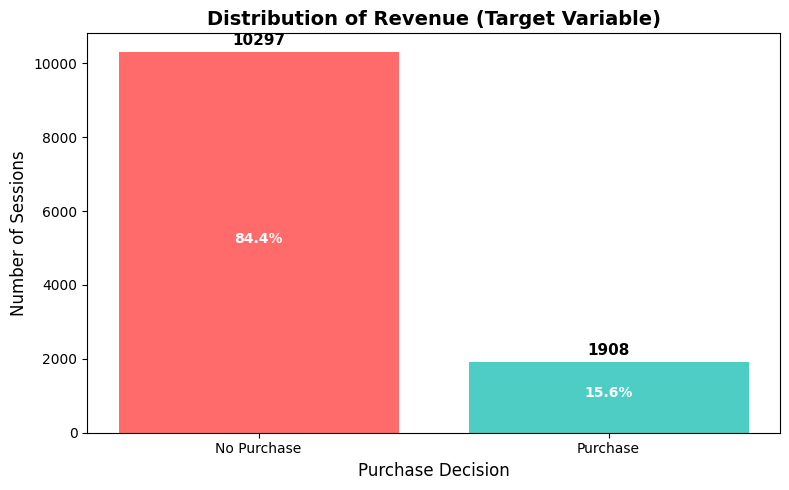

In [15]:
# visualize target variable distribution
plt.figure(figsize=(8, 5))
revenue_counts = df_clean['Revenue'].value_counts()
plt.bar(['No Purchase', 'Purchase'], revenue_counts.values, color=['#FF6B6B', '#4ECDC4'])
plt.title('Distribution of Revenue (Target Variable)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Sessions', fontsize=12)
plt.xlabel('Purchase Decision', fontsize=12)

# add value labels on bars
for i, v in enumerate(revenue_counts.values):
    plt.text(i, v + 200, str(v), ha='center', fontsize=11, fontweight='bold')
    percentage = (v / len(df_clean)) * 100
    plt.text(i, v/2, f'{percentage:.1f}%', ha='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.show()


The target variable shows significant class imbalance with 84.4% non-purchase sessions and 15.6% purchase sessions. This imbalance is typical in e-commerce where most visitors browse without buying. This will be important to address during modeling, potentially using techniques like SMOTE or class weighting.


##### **Administrative Pages**

Administrative pages typically include account management, login, and registration pages. Understanding how users interact with these pages can provide insights into user engagement.


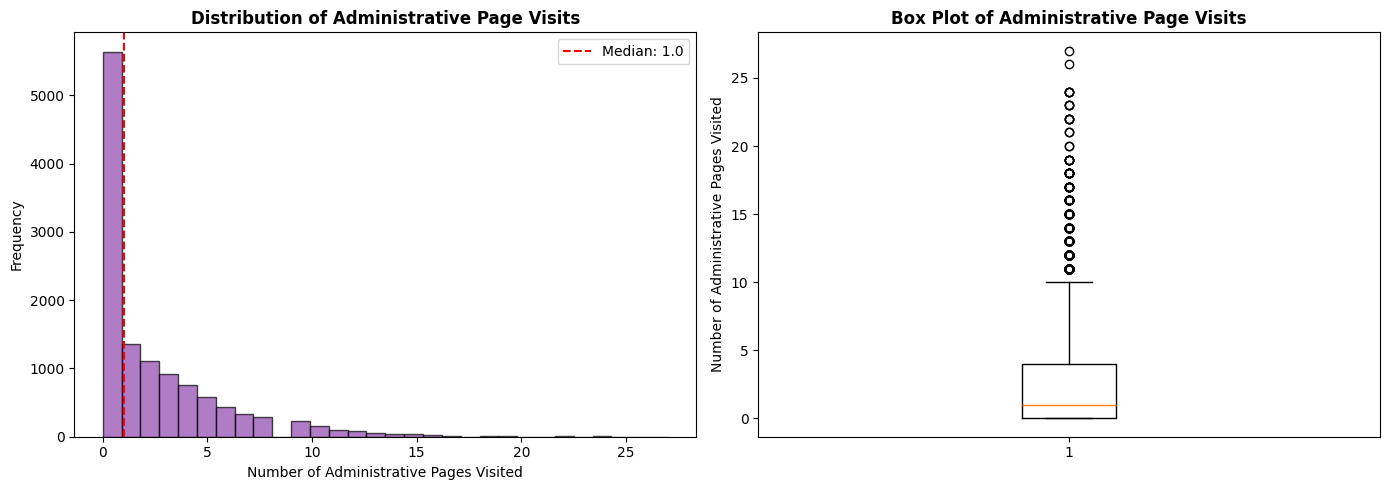

Mean: 2.34
Median: 1.00
Std: 3.33


In [16]:
# distribution of Administrative pages visited
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df_clean['Administrative'], bins=30, color='#8e44ad', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Administrative Page Visits', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Administrative Pages Visited', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df_clean['Administrative'].median(), color='red', linestyle='--', 
                label=f'Median: {df_clean["Administrative"].median()}')
axes[0].legend()

# box plot
axes[1].boxplot(df_clean['Administrative'], vert=True)
axes[1].set_title('Box Plot of Administrative Page Visits', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Administrative Pages Visited', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean: {df_clean['Administrative'].mean():.2f}")
print(f"Median: {df_clean['Administrative'].median():.2f}")
print(f"Std: {df_clean['Administrative'].std():.2f}")

The distribution of Administrative page visits is highly right-skewed, with the majority of user sessions visiting very few administrative pages. The median value is low, indicating that most users spend limited time on administrative content, while a small number of sessions show unusually high page visits, appearing as outliers. This suggests that administrative pages are not the primary focus for most users but may be heavily used by a small subset of visitors.


##### **Administrative_Duration**

This feature represents the total time spent on administrative pages during a session.


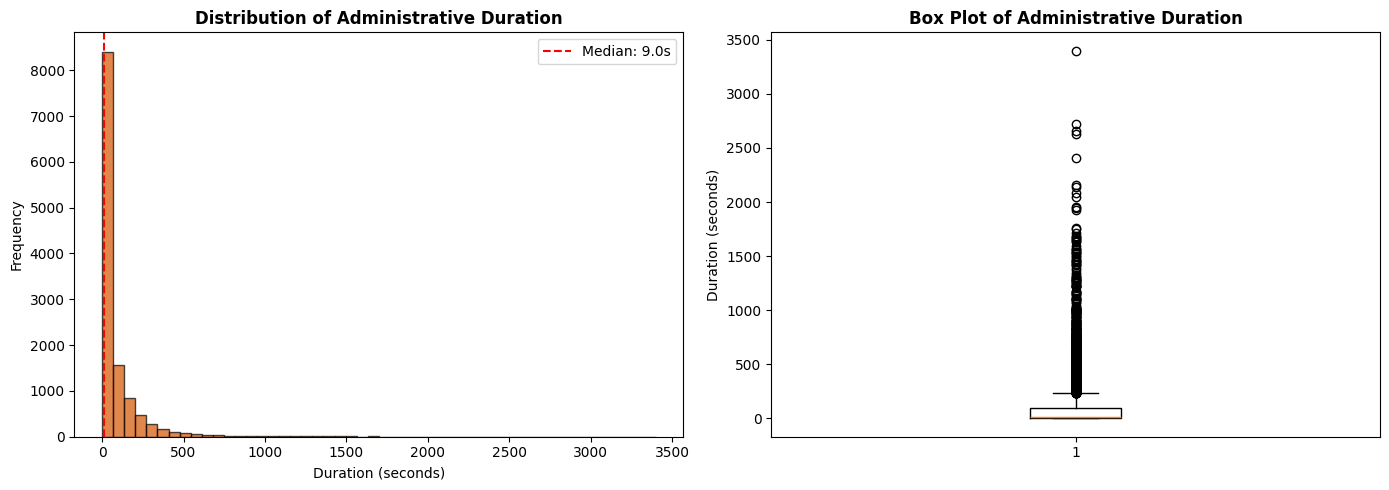

Mean: 81.65 seconds
Median: 9.00 seconds


In [17]:
# distribution of Administrative_Duration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df_clean['Administrative_Duration'], bins=50, color='#d35400', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Administrative Duration', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Duration (seconds)', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df_clean['Administrative_Duration'].median(), color='red', linestyle='--', 
                label=f'Median: {df_clean["Administrative_Duration"].median():.1f}s')
axes[0].legend()

# box plot
axes[1].boxplot(df_clean['Administrative_Duration'], vert=True)
axes[1].set_title('Box Plot of Administrative Duration', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Duration (seconds)', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean: {df_clean['Administrative_Duration'].mean():.2f} seconds")
print(f"Median: {df_clean['Administrative_Duration'].median():.2f} seconds")

The distribution of Administrative Duration is highly right-skewed, with the majority of sessions showing very short durations near zero seconds, and frequency declining rapidly as duration increases up to around 3,500 seconds. The median value of 9.0 seconds highlights limited typical engagement with administrative content, while the box plot displays a compact interquartile range and numerous outliers at higher values, indicating that most users interact briefly with these pages, but a small subset exhibits prolonged activity that could reflect specific user behaviors or session types.


##### **Informational Pages**

Informational pages include content like FAQs, shipping information, and about pages. These help users make informed decisions.


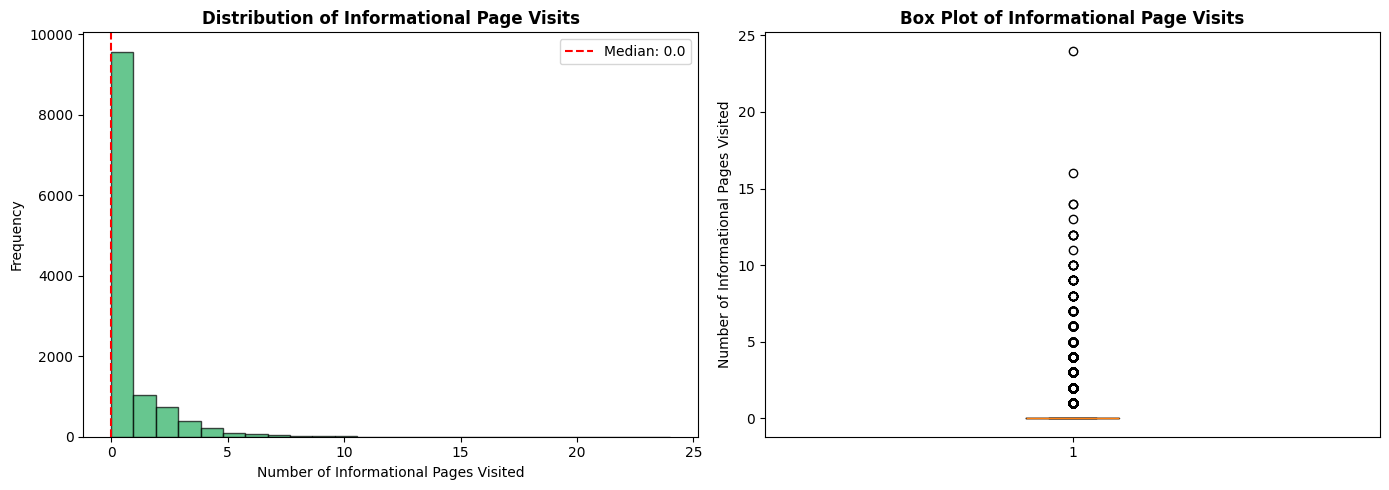

Mean: 0.51
Median: 0.00
Std: 1.28


In [18]:
# distribution of Informational pages visited
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df_clean['Informational'], bins=25, color='#27ae60', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Informational Page Visits', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Informational Pages Visited', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df_clean['Informational'].median(), color='red', linestyle='--', 
                label=f'Median: {df_clean["Informational"].median()}')
axes[0].legend()

# box plot
axes[1].boxplot(df_clean['Informational'], vert=True)
axes[1].set_title('Box Plot of Informational Page Visits', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Informational Pages Visited', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean: {df_clean['Informational'].mean():.2f}")
print(f"Median: {df_clean['Informational'].median():.2f}")
print(f"Std: {df_clean['Informational'].std():.2f}")

The distribution is extremely right-skewed with a median of 0, where ~85–90% of sessions visit zero informational pages and frequency drops sharply beyond 5 pages. The box plot confirms a very narrow interquartile range tightly clustered at zero, with only a small number of extreme outliers reaching up to 25 pages, indicating that the vast majority of users show almost no engagement with informational content, while a tiny subset exhibits rare, prolonged interaction.


##### **Informational_Duration**

This measures the time spent reading informational content during a session.


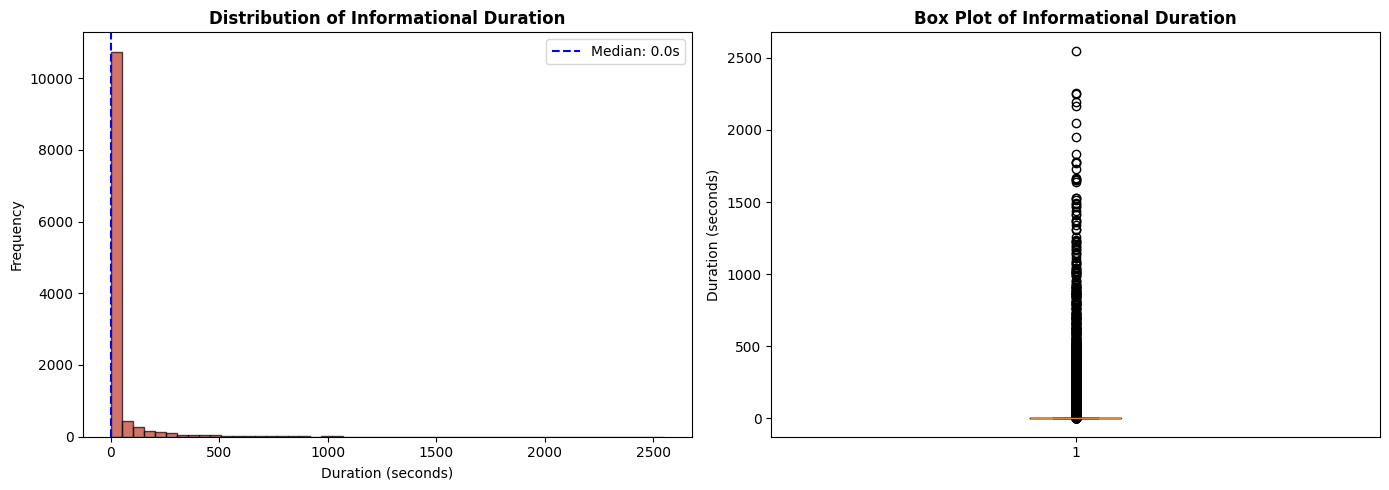

Mean: 34.83 seconds
Median: 0.00 seconds


In [19]:
# distribution of Informational_Duration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df_clean['Informational_Duration'], bins=50, color='#c0392b', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Informational Duration', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Duration (seconds)', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df_clean['Informational_Duration'].median(), color='blue', linestyle='--', 
                label=f'Median: {df_clean["Informational_Duration"].median():.1f}s')
axes[0].legend()

# box plot
axes[1].boxplot(df_clean['Informational_Duration'], vert=True)
axes[1].set_title('Box Plot of Informational Duration', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Duration (seconds)', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean: {df_clean['Informational_Duration'].mean():.2f} seconds")
print(f"Median: {df_clean['Informational_Duration'].median():.2f} seconds")

The distribution is extremely right-skewed with a median of 0.0 seconds, where the vast majority of sessions show zero time spent on informational pages and frequency drops rapidly beyond short durations. The box plot reveals a very narrow interquartile range tightly clustered at zero, with numerous extreme outliers extending up to ~2,500 seconds, indicating that almost all users spend negligible time on informational content while only a very small subset exhibits significantly prolonged engagement.


##### **ProductRelated**

These features track user interaction with product pages, which are likely strong predictors of purchase behavior.


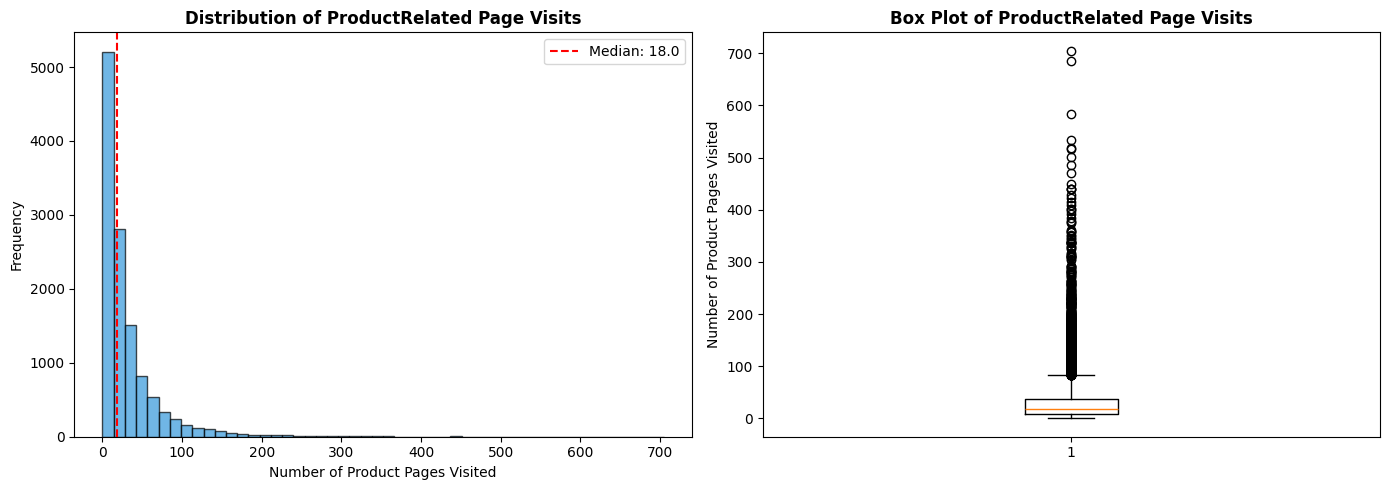

Mean: 32.05
Median: 18.00
Std: 44.59


In [20]:
# distribution of ProductRelated pages visited
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df_clean['ProductRelated'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of ProductRelated Page Visits', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Product Pages Visited', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df_clean['ProductRelated'].median(), color='red', linestyle='--', 
                label=f'Median: {df_clean["ProductRelated"].median()}')
axes[0].legend()

# box plot
axes[1].boxplot(df_clean['ProductRelated'], vert=True)
axes[1].set_title('Box Plot of ProductRelated Page Visits', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Product Pages Visited', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean: {df_clean['ProductRelated'].mean():.2f}")
print(f"Median: {df_clean['ProductRelated'].median():.2f}")
print(f"Std: {df_clean['ProductRelated'].std():.2f}")


The distribution is right-skewed with a median of 18.0 pages, showing that most sessions involve moderate browsing of product-related pages (peak around 10–30 pages) while frequency declines gradually toward higher values up to ~700. The box plot displays a wider interquartile range centered around the median, with numerous extreme outliers extending far above 200–500 pages, indicating that while the typical user shows focused product exploration, a notable subset engages in very extensive browsing behavior.


##### **ProductRelated_Duration**


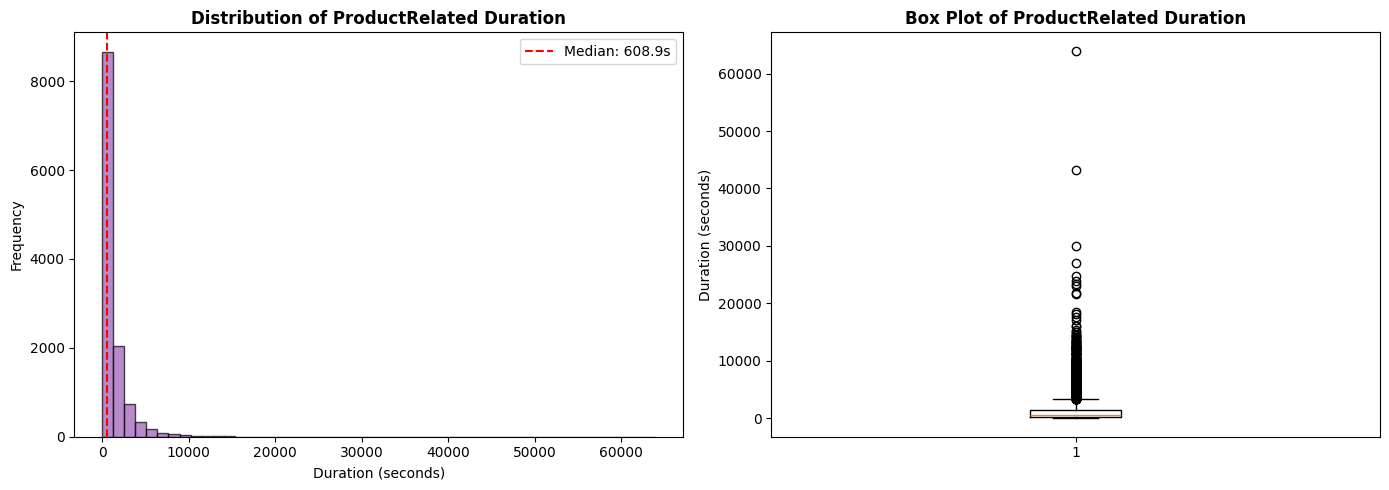

Mean: 1206.98 seconds
Median: 608.94 seconds


In [21]:
# distribution of ProductRelated_Duration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram with log scale for better visualization
axes[0].hist(df_clean['ProductRelated_Duration'], bins=50, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of ProductRelated Duration', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Duration (seconds)', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df_clean['ProductRelated_Duration'].median(), color='red', linestyle='--', 
                label=f'Median: {df_clean["ProductRelated_Duration"].median():.1f}s')
axes[0].legend()

# box plot
axes[1].boxplot(df_clean['ProductRelated_Duration'], vert=True)
axes[1].set_title('Box Plot of ProductRelated Duration', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Duration (seconds)', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean: {df_clean['ProductRelated_Duration'].mean():.2f} seconds")
print(f"Median: {df_clean['ProductRelated_Duration'].median():.2f} seconds")


The distribution is strongly right-skewed with a median of 608.9 seconds, showing that most sessions involve moderate time spent on product-related pages while frequency declines rapidly toward very long durations. The box plot reveals a wide interquartile range with the median near 609 seconds, and numerous extreme outliers extending up to ~60,000 seconds, indicating that while typical users spend a reasonable amount of time exploring products, a small but significant subset exhibits exceptionally prolonged engagement.


##### **BounceRates (Engagement Metric)**

BounceRate indicates the percentage of visitors who leave immediately. Lower bounce rates typically suggest better engagement.


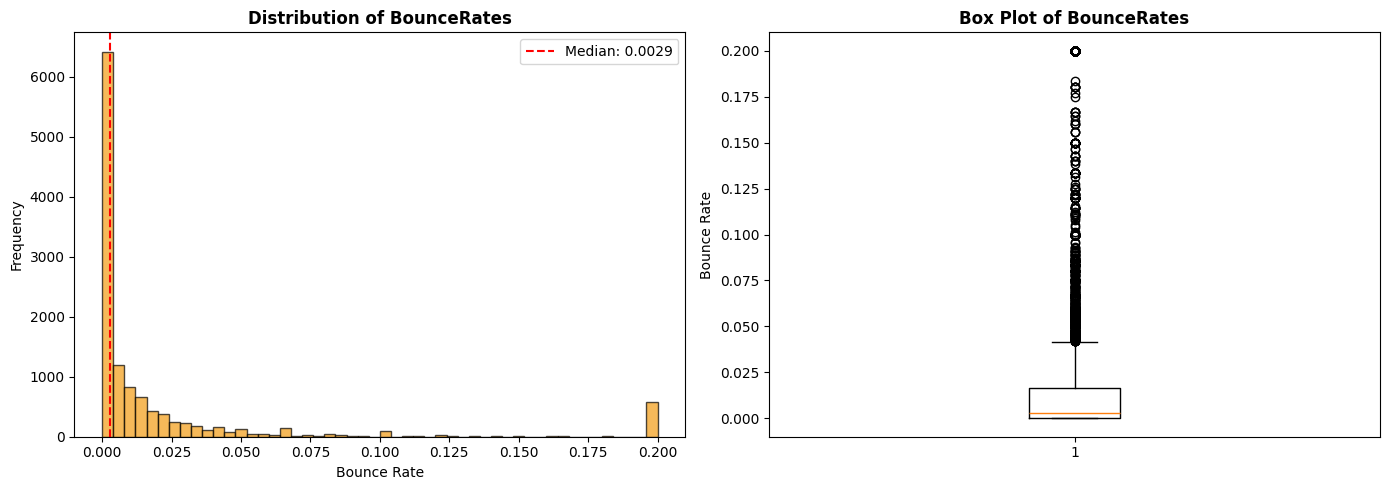

Mean: 0.0204
Median: 0.0029


In [22]:
# distribution of BounceRates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df_clean['BounceRates'], bins=50, color='#f39c12', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of BounceRates', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Bounce Rate', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df_clean['BounceRates'].median(), color='red', linestyle='--', 
                label=f'Median: {df_clean["BounceRates"].median():.4f}')
axes[0].legend()

# box plot
axes[1].boxplot(df_clean['BounceRates'], vert=True)
axes[1].set_title('Box Plot of BounceRates', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Bounce Rate', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean: {df_clean['BounceRates'].mean():.4f}")
print(f"Median: {df_clean['BounceRates'].median():.4f}")

The distribution is strongly right-skewed with a median of 0.0029, showing that most sessions have very low bounce rates (peak near 0–0.025) while a long tail extends to higher values with a small secondary peak around 0.20. The box plot displays a narrow interquartile range tightly clustered near zero, with numerous extreme outliers reaching up to 0.20, indicating that the majority of users exhibit low bounce behavior, while a notable subset experiences significantly higher bounce rates suggestive of disengagement.


##### **ExitRates (Session Ending Metric)**

ExitRate measures the percentage of pageviews that were the last in the session. This helps identify pages where users leave the site.


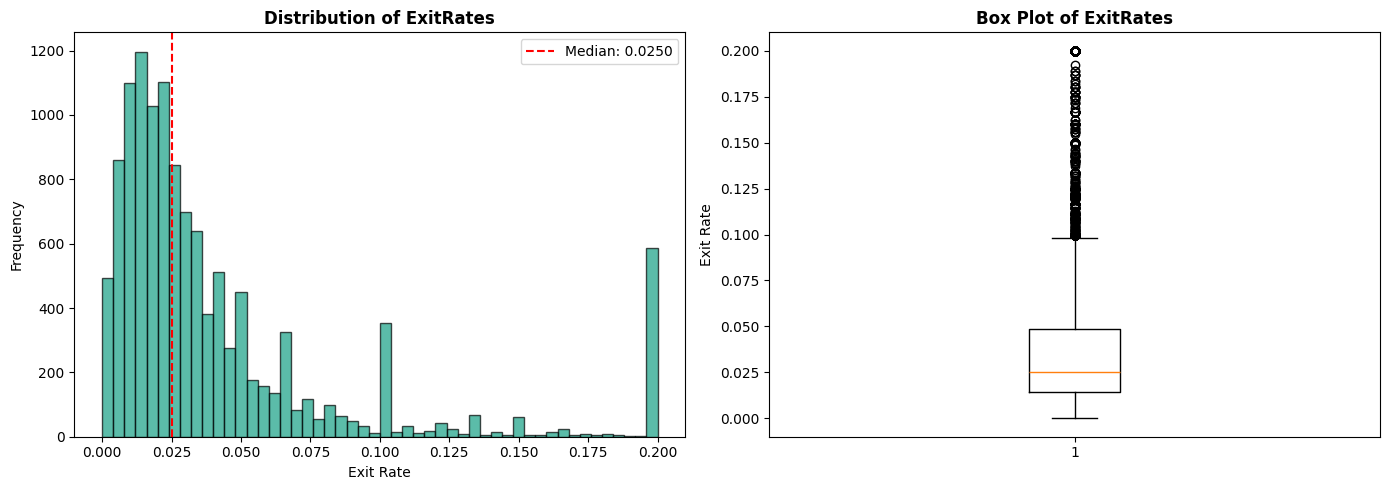

Mean: 0.0415
Median: 0.0250


In [23]:
# distribution of ExitRates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df_clean['ExitRates'], bins=50, color='#16a085', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of ExitRates', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Exit Rate', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df_clean['ExitRates'].median(), color='red', linestyle='--', 
                label=f'Median: {df_clean["ExitRates"].median():.4f}')
axes[0].legend()

# box plot
axes[1].boxplot(df_clean['ExitRates'], vert=True)
axes[1].set_title('Box Plot of ExitRates', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Exit Rate', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean: {df_clean['ExitRates'].mean():.4f}")
print(f"Median: {df_clean['ExitRates'].median():.4f}")

The distribution is right-skewed with a median of 0.0250, showing a broad spread where many sessions have low to moderate exit rates (peak around 0.00–0.05) and a noticeable secondary peak at 0.20. The box plot displays a wider interquartile range centered near 0.025, with numerous extreme outliers extending up to 0.20, indicating that while typical sessions have relatively low exit rates, a substantial subset of users experiences significantly higher exit behavior suggestive of lower purchase intent.

##### **PageValues (Transaction Value Indicator)**

PageValues represents the average value of pages visited before a transaction. This is a critical feature as it directly relates to purchase intent.


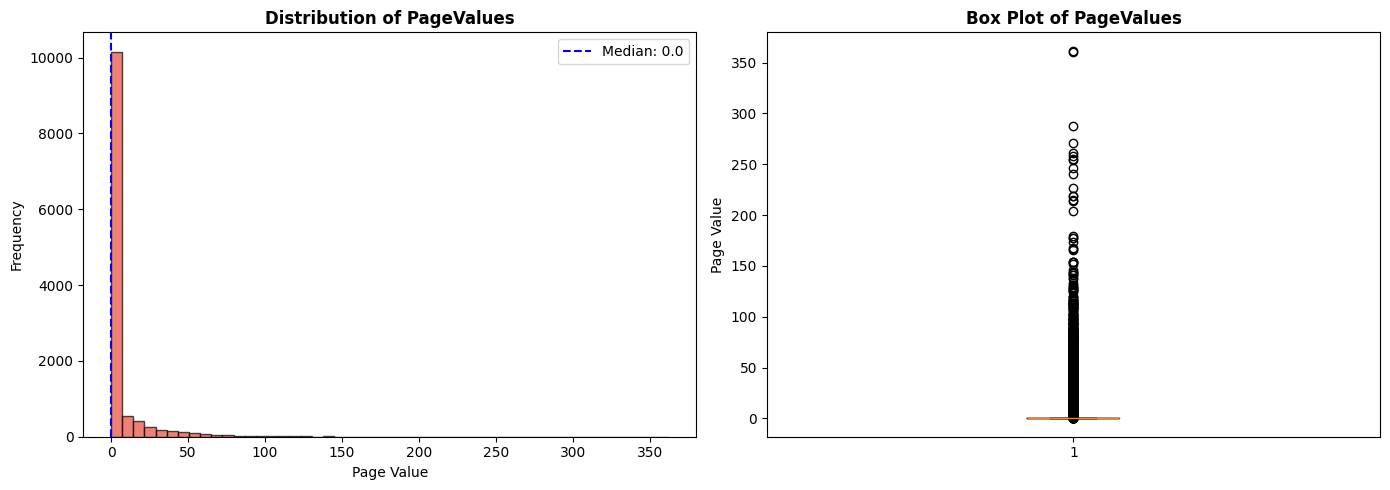

Mean: 5.95
Median: 0.00
Non-zero PageValues: 2730 (22.4%)


In [24]:
# distribution of PageValues
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df_clean['PageValues'], bins=50, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of PageValues', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Page Value', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].axvline(df_clean['PageValues'].median(), color='blue', linestyle='--', 
                label=f'Median: {df_clean["PageValues"].median():.1f}')
axes[0].legend()

# box plot
axes[1].boxplot(df_clean['PageValues'], vert=True)
axes[1].set_title('Box Plot of PageValues', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Page Value', fontsize=10)

plt.tight_layout()
plt.show()

# statistics
print(f"Mean: {df_clean['PageValues'].mean():.2f}")
print(f"Median: {df_clean['PageValues'].median():.2f}")
print(f"Non-zero PageValues: {(df_clean['PageValues'] > 0).sum()} ({(df_clean['PageValues'] > 0).sum() / len(df_clean) * 100:.1f}%)")

PageValues is highly skewed with median of 0, meaning 77.6% of sessions have zero page value (no purchase intent tracked). Only 22.4% of sessions show non-zero values, which aligns with our purchase rate. This feature will be a strong predictor for classification.


##### **SpecialDay**

SpecialDay indicates the closeness of the session to special occasions like Valentine's Day or Mother's Day, which may influence shopping behavior.


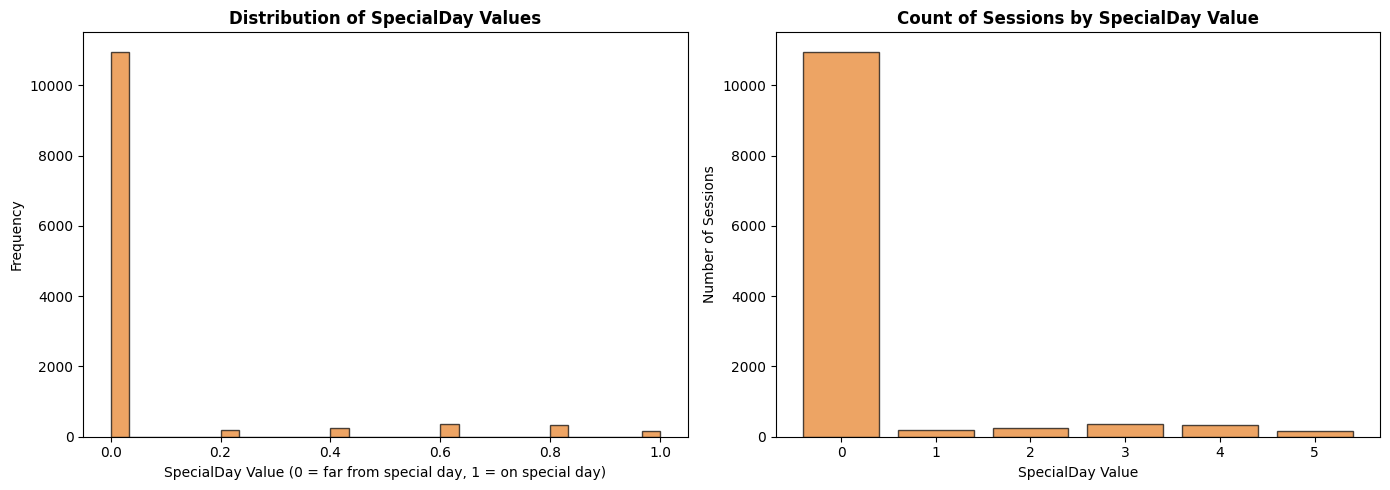

Mean: 0.0619
Median: 0.0000

Sessions with SpecialDay = 0: 10956 (89.8%)
Sessions with SpecialDay > 0: 1249 (10.2%)


In [25]:
# distribution of SpecialDay
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(df_clean['SpecialDay'], bins=30, color='#e67e22', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of SpecialDay Values', fontsize=12, fontweight='bold')
axes[0].set_xlabel('SpecialDay Value (0 = far from special day, 1 = on special day)', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)

# value counts
special_day_counts = df_clean['SpecialDay'].value_counts().sort_index()
axes[1].bar(range(len(special_day_counts)), special_day_counts.values, color='#e67e22', edgecolor='black', alpha=0.7)
axes[1].set_title('Count of Sessions by SpecialDay Value', fontsize=12, fontweight='bold')
axes[1].set_xlabel('SpecialDay Value', fontsize=10)
axes[1].set_ylabel('Number of Sessions', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean: {df_clean['SpecialDay'].mean():.4f}")
print(f"Median: {df_clean['SpecialDay'].median():.4f}")
print(f"\nSessions with SpecialDay = 0: {(df_clean['SpecialDay'] == 0).sum()} ({(df_clean['SpecialDay'] == 0).sum() / len(df_clean) * 100:.1f}%)")
print(f"Sessions with SpecialDay > 0: {(df_clean['SpecialDay'] > 0).sum()} ({(df_clean['SpecialDay'] > 0).sum() / len(df_clean) * 100:.1f}%)")

SpecialDay shows that the vast majority of sessions occur far from special occasions (value = 0). Only a small number of sessions are close to special days like Valentine's Day or Mother's Day. This suggests most data was collected during regular shopping periods, though the few sessions near special days may show different purchasing patterns worth investigating in bivariate analysis.


##### **Month (Seasonal Patterns)**

Understanding the temporal distribution of sessions can reveal seasonal shopping trends.


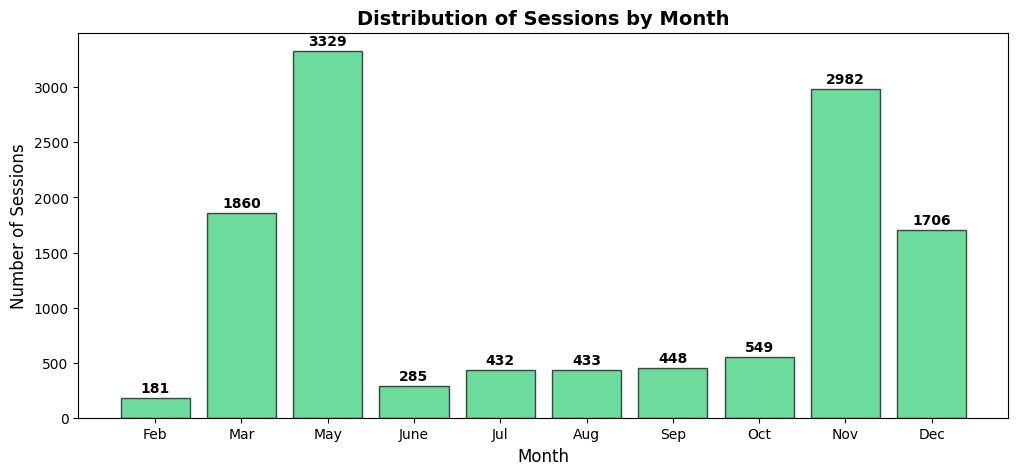


Session counts by month:
Month
Feb      181
Mar     1860
May     3329
June     285
Jul      432
Aug      433
Sep      448
Oct      549
Nov     2982
Dec     1706
Name: count, dtype: int64


In [26]:
# distribution of sessions by month
month_order = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_counts = df_clean['Month'].value_counts().reindex(month_order)

plt.figure(figsize=(12, 5))
plt.bar(month_counts.index, month_counts.values, color='#2ecc71', edgecolor='black', alpha=0.7)
plt.title('Distribution of Sessions by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)

# add value labels on bars
for i, v in enumerate(month_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout
plt.show()

print("\nSession counts by month:")
print(month_counts)

The bar chart shows that shopping activity peaks in **May and November**, with over 3,000 sessions each, suggesting strong seasonal trends potentially linked to shopping events. Activity is lowest in **February**, which might indicate post-holiday shopping fatigue. This **seasonal pattern** is important for understanding when users are most likely to visit the site.


##### **OperatingSystems**

Understanding which operating systems visitors use helps optimize website compatibility and user experience across different platforms.


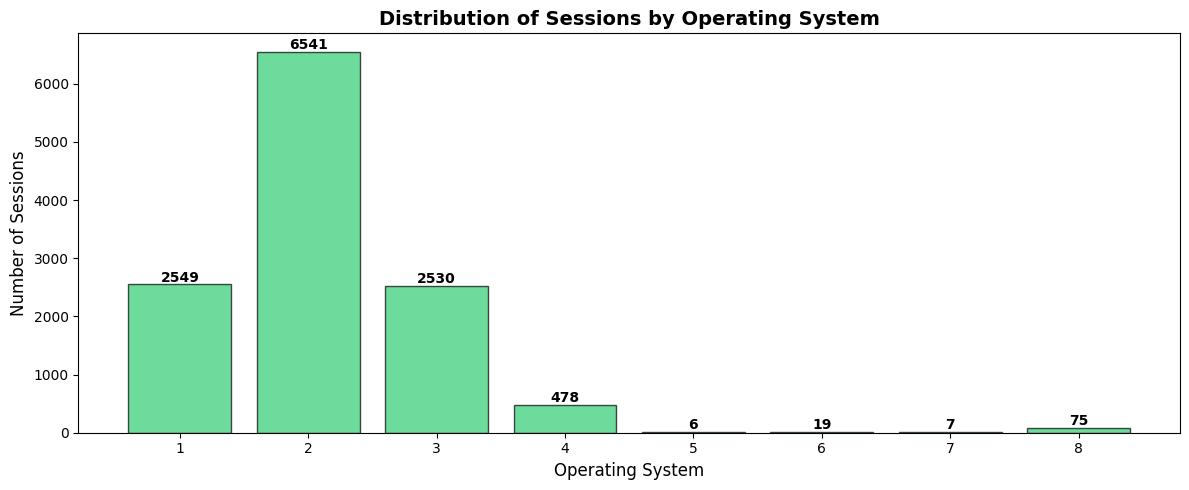


Session counts by Operating System:
OperatingSystems
1    2549
2    6541
3    2530
4     478
5       6
6      19
7       7
8      75
Name: count, dtype: int64


In [27]:
# distribution of sessions by OS
os_counts = df_clean['OperatingSystems'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.bar(os_counts.index, os_counts.values, color='#2ecc71', edgecolor='black', alpha=0.7)
plt.title('Distribution of Sessions by Operating System', fontsize=14, fontweight='bold')
plt.xlabel('Operating System', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)

# add value labels on bars
for i, v in enumerate(os_counts.values):
    plt.text(os_counts.index[i], v + 50, str(v), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nSession counts by Operating System:")
print(os_counts)

The operating system distribution shows **moderate class imbalance** with **OS 2** dominating at 4,500+ sessions (37%), **OS 1** and **OS 3** with 2,500-3,000 sessions each (20-24%), while OS 4-8 have minimal representation (<1,000 sessions). This distribution pattern suggests that OperatingSystems could provide moderate predictive value, as the top 3 OS platforms represent ~80% of traffic. However, rare OS categories may need to be grouped into an "Other" category during feature engineering to prevent overfitting and improve model generalization. For clustering analysis, OS differences may help segment users by device/platform preferences alongside behavioral patterns.


##### **Browser**

Browser indicates which web browser visitors use to access the site.


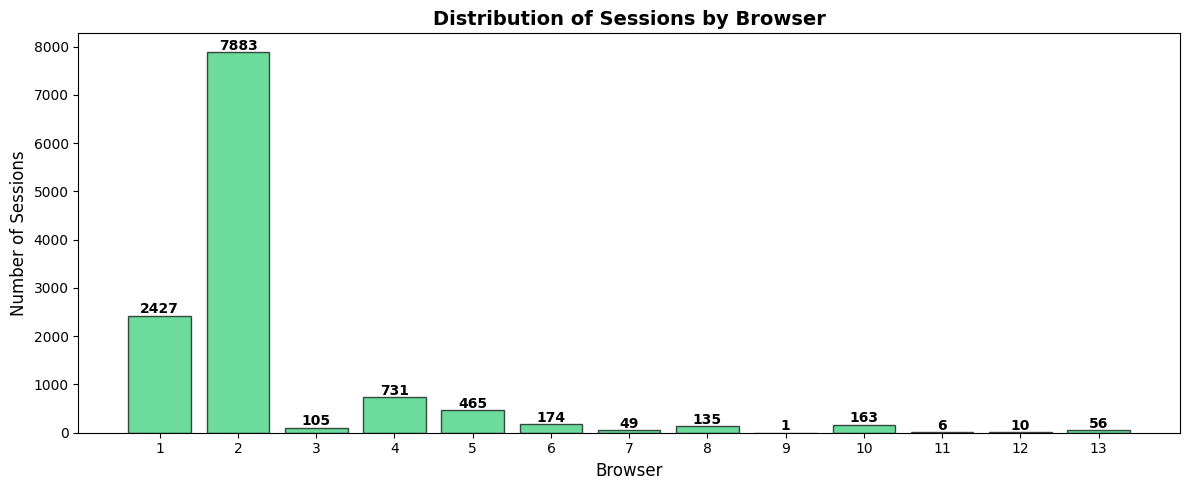


Session counts by Browser:
Browser
1     2427
2     7883
3      105
4      731
5      465
6      174
7       49
8      135
9        1
10     163
11       6
12      10
13      56
Name: count, dtype: int64


In [28]:
# distribution of sessions by Browser
browser_counts = df_clean['Browser'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.bar(browser_counts.index, browser_counts.values, color='#2ecc71', edgecolor='black', alpha=0.7)
plt.title('Distribution of Sessions by Browser', fontsize=14, fontweight='bold')
plt.xlabel('Browser', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)

# set all browser IDs on x-axis
plt.xticks(browser_counts.index)

# add value labels on bars
for i, v in enumerate(browser_counts.values):
    plt.text(browser_counts.index[i], v + 50, str(v), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nSession counts by Browser:")
print(browser_counts)

The browser distribution reveals **extreme class imbalance** with **Browser 2** dominating at over 5,000 sessions (41%), **Browser 1** with approximately 2,000 sessions (16%), while browsers 3-13 each have fewer than 500 sessions. This **highly skewed distribution** creates a modeling challenge, as browsers with minimal representation may not provide sufficient signal for predicting purchasing behavior. For classification and clustering tasks, this suggests Browser may have limited predictive power as a standalone feature, though interaction effects with other variables could still be valuable. Feature engineering approaches such as grouping rare browsers or treating Browser as a binary feature (major vs. minor) may improve model performance.


##### **Region**

Region represents the geographical location of visitors accessing the e-commerce site. Analyzing regional distribution helps identify key markets and supports targeted regional marketing strategies.


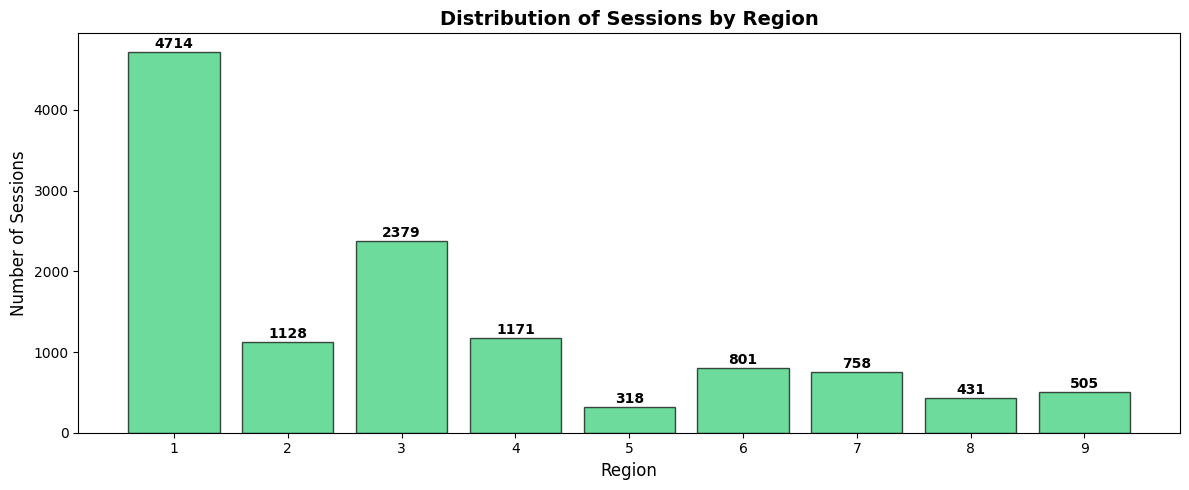


Session counts by Region:
Region
1    4714
2    1128
3    2379
4    1171
5     318
6     801
7     758
8     431
9     505
Name: count, dtype: int64


In [29]:
# distribution of sessions by Region
region_counts = df_clean['Region'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.bar(region_counts.index, region_counts.values, color='#2ecc71', edgecolor='black', alpha=0.7)
plt.title('Distribution of Sessions by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)

# set all region IDs on x-axis
plt.xticks(region_counts.index)

# add value labels on bars
for i, v in enumerate(region_counts.values):
    plt.text(region_counts.index[i], v + 50, str(v), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nSession counts by Region:")
print(region_counts)

The regional distribution exhibits **high cardinality** with 9 regions showing varied representation: **Region 1** leads with ~3,500 sessions (28%), **Region 3** with ~2,000 sessions (16%), and several moderate regions with 500-1,500 sessions. This geographic diversity presents both opportunities and challenges. The relatively balanced distribution across multiple regions (compared to Browser/OS) suggests Region could be a useful feature for both classification and clustering tasks, potentially capturing location-based purchasing patterns. However, regions with very low counts may benefit from grouping or regularization techniques. In clustering, regional patterns combined with behavioral metrics could reveal geographically-distinct customer segments.


##### **TrafficType**

TrafficType indicates the source channel through which visitors arrived at the site (e.g., direct traffic, search engines, social media, referrals, or paid advertising). Understanding traffic sources helps optimize marketing channels and acquisition strategies.


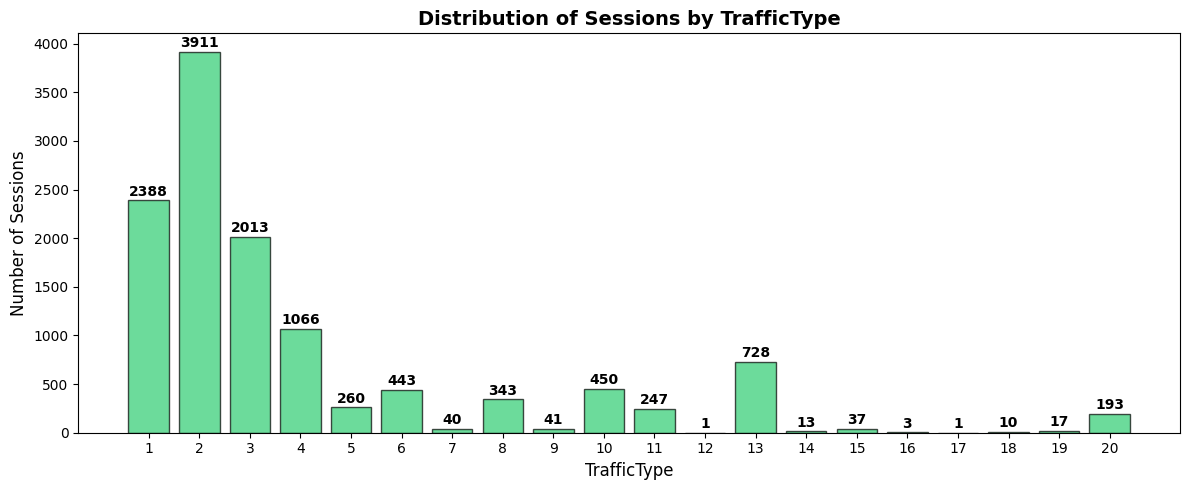


Session counts by TrafficType:
TrafficType
1     2388
2     3911
3     2013
4     1066
5      260
6      443
7       40
8      343
9       41
10     450
11     247
12       1
13     728
14      13
15      37
16       3
17       1
18      10
19      17
20     193
Name: count, dtype: int64


In [30]:

# distribution of sessions by TrafficType
traffic_counts = df_clean['TrafficType'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.bar(traffic_counts.index, traffic_counts.values, color='#2ecc71', edgecolor='black', alpha=0.7)
plt.title('Distribution of Sessions by TrafficType', fontsize=14, fontweight='bold')
plt.xlabel('TrafficType', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)

# set all TrafficType IDs on x-axis
plt.xticks(traffic_counts.index)

# add value labels on bars
for i, v in enumerate(traffic_counts.values):
    plt.text(traffic_counts.index[i], v + 50, str(v), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nSession counts by TrafficType:")
print(traffic_counts)

The traffic type distribution shows **very high cardinality** with 20 distinct traffic sources, where **Traffic Type 2** dominates (4,000+ sessions, 33%), followed by **Types 1 and 3** (~2,000 sessions each, 16% each), while most others have <1,000 sessions. This **extremely sparse feature space** presents significant modeling challenges: many rare traffic types provide insufficient samples for reliable pattern learning. For **classification models**, this suggests TrafficType should undergo aggressive dimensionality reduction—either grouping rare categories (e.g., "Top 3" vs "Other") or using target encoding to capture purchase likelihood per traffic source. For **clustering**, traffic source may help identify acquisition-based segments but should be combined with behavioral features to avoid over-segmentation.


##### **VisitorType (User Segmentation)**

VisitorType categorizes users as returning visitors, new visitors, or other. This may influence purchase behavior.


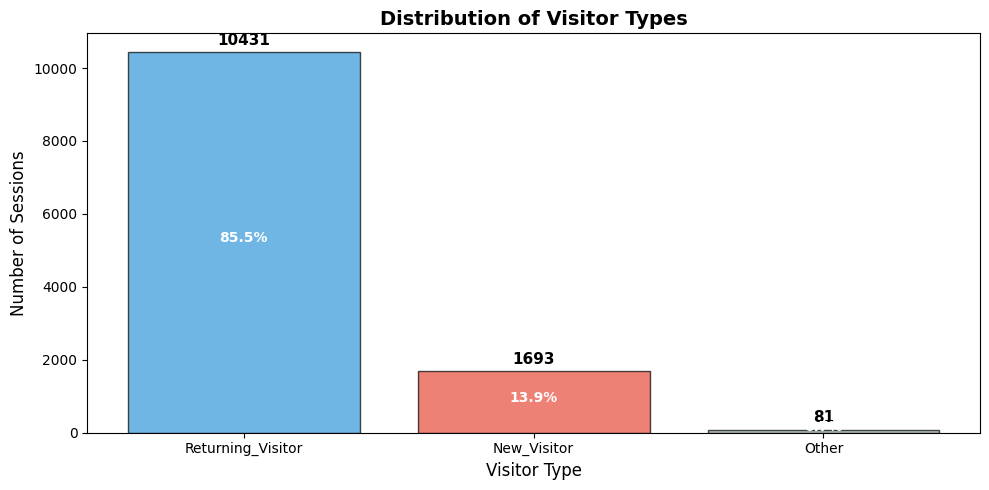

Visitor type distribution:
VisitorType
Returning_Visitor    10431
New_Visitor           1693
Other                   81
Name: count, dtype: int64

Percentages:
VisitorType
Returning_Visitor    85.464973
New_Visitor          13.871364
Other                 0.663662
Name: count, dtype: float64


In [31]:
# distribution of VisitorType
visitor_counts = df_clean['VisitorType'].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(visitor_counts.index, visitor_counts.values, color=['#3498db', '#e74c3c', '#95a5a6'], 
        edgecolor='black', alpha=0.7)
plt.title('Distribution of Visitor Types', fontsize=14, fontweight='bold')
plt.xlabel('Visitor Type', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)

# add value labels on bars
for i, v in enumerate(visitor_counts.values):
    plt.text(i, v + 200, str(v), ha='center', fontsize=11, fontweight='bold')
    percentage = (v / len(df_clean)) * 100
    plt.text(i, v/2, f'{percentage:.1f}%', ha='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print("Visitor type distribution:")
print(visitor_counts)
print(f"\nPercentages:")
print(visitor_counts / len(df_clean) * 100)


The majority of sessions are from returning visitors (85.5%), with only 13.9% from new visitors. This suggests the website has a strong repeat visitor base. The "Other" category is minimal (0.7%). This imbalance may influence purchase patterns and will be important for clustering analysis.


##### **Weekend (Temporal Pattern)**

Understanding whether sessions occur on weekends versus weekdays may reveal different shopping behaviors.


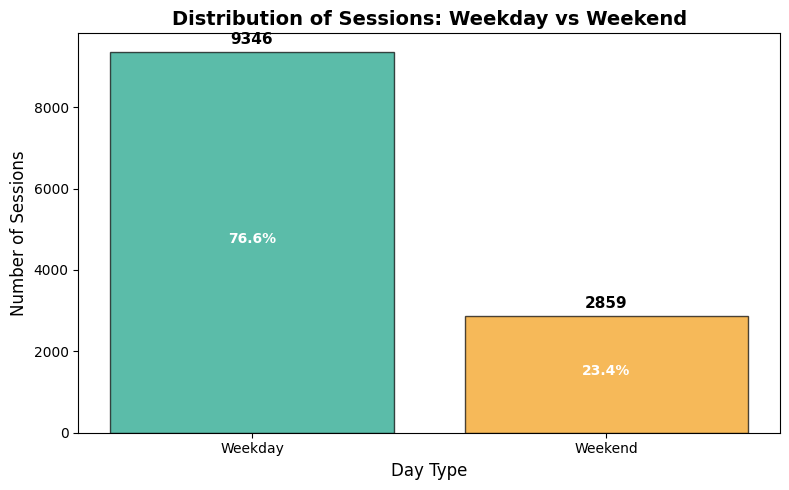

Weekend distribution:
Weekend
False    9346
True     2859
Name: count, dtype: int64

Percentages:
Weekend
False    76.575174
True     23.424826
Name: count, dtype: float64


In [32]:
# distribution of Weekend sessions
weekend_counts = df_clean['Weekend'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(['Weekday', 'Weekend'], weekend_counts.values, color=['#16a085', '#f39c12'], 
        edgecolor='black', alpha=0.7)
plt.title('Distribution of Sessions: Weekday vs Weekend', fontsize=14, fontweight='bold')
plt.xlabel('Day Type', fontsize=12)
plt.ylabel('Number of Sessions', fontsize=12)

# add value labels on bars
for i, v in enumerate(weekend_counts.values):
    plt.text(i, v + 200, str(v), ha='center', fontsize=11, fontweight='bold')
    percentage = (v / len(df_clean)) * 100
    plt.text(i, v/2, f'{percentage:.1f}%', ha='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print("Weekend distribution:")
print(weekend_counts)
print(f"\nPercentages:")
print(weekend_counts / len(df_clean) * 100)


Most sessions occur on weekdays (76.6%) compared to weekends (23.4%). This is expected for online shopping, though weekend sessions might show different purchasing behaviors worth investigating in bivariate analysis.


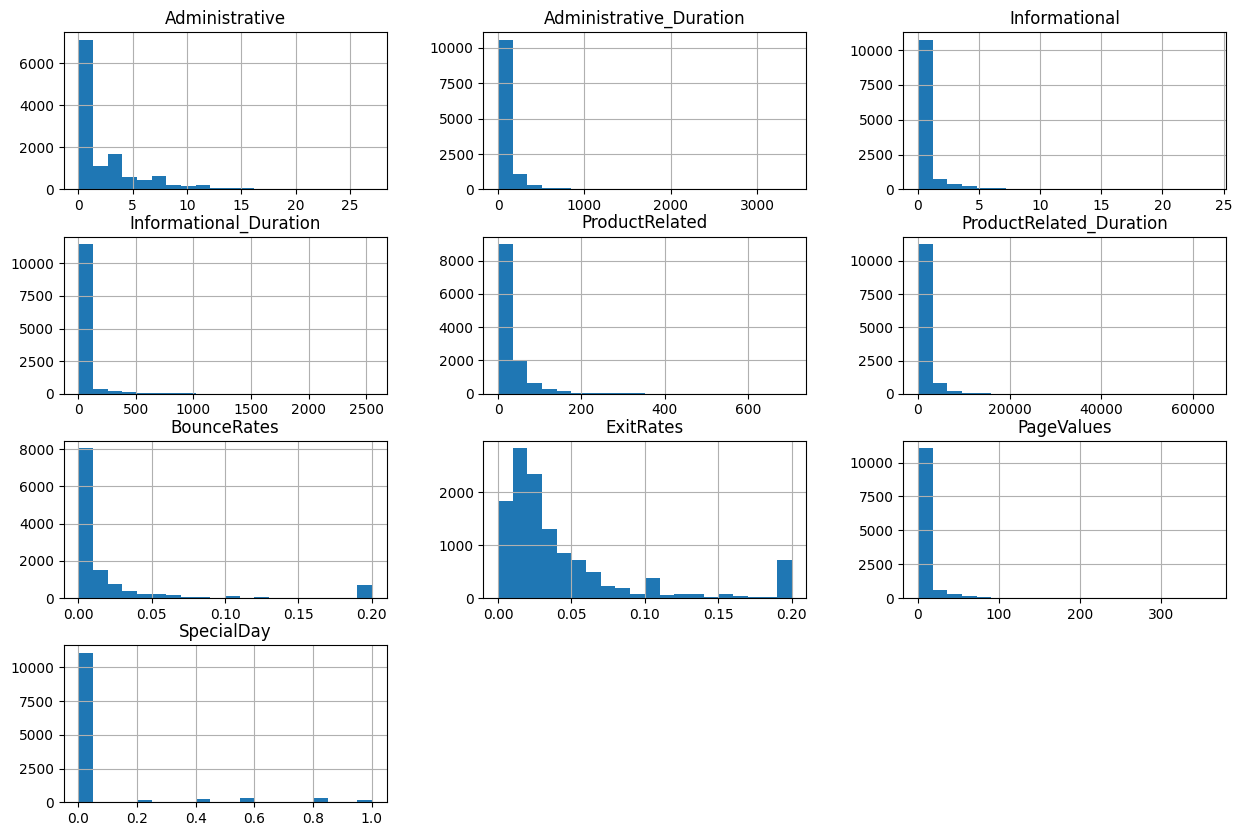

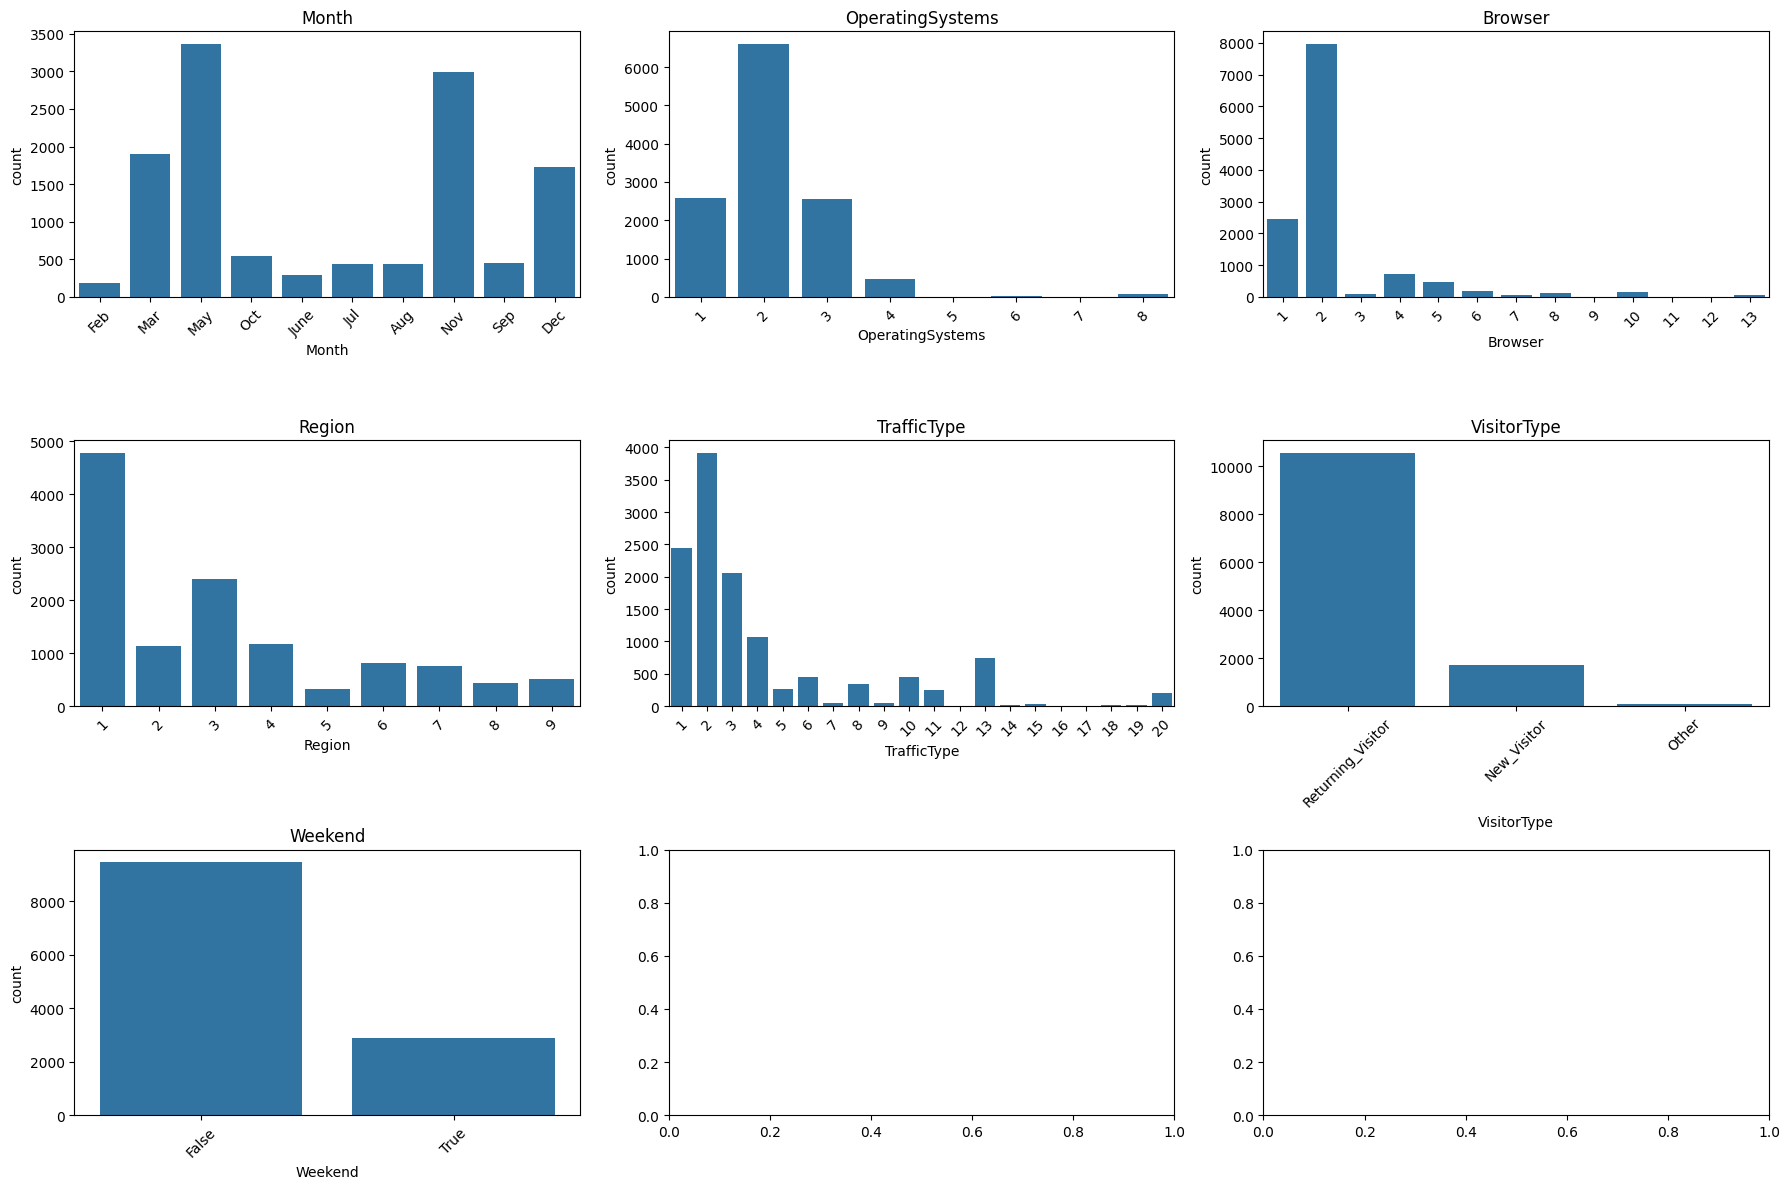

In [33]:
# Visualize numerical features
numerical_cols = ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration',
                  'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
df[numerical_cols].hist(bins=20, figsize=(15, 10))
plt.show()

# Categorical features distribution
categorical_cols = ['Month', 'OperatingSystems', 'Browser', 'Region',
                    'TrafficType', 'VisitorType', 'Weekend']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.ravel()

for ax, col in zip(axes, categorical_cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

##### **Quick insights per feature**

- Administrative: Most sessions view few admin pages; a small group visits many.  
- Administrative_Duration: Typical time on admin pages is very low; long sessions are outliers.  
- Informational: Majority of sessions view zero informational pages.  
- Informational_Duration: Time on info pages is near zero for most users; few spend long periods.  
- ProductRelated: Product page views are a strong signal—higher counts correlate with purchases.  
- ProductRelated_Duration: More time on product pages strongly indicates purchase intent.  
- BounceRates: Low bounce rates are associated with higher conversion likelihood.  
- ExitRates: Lower exit rates correlate with higher purchase probability.  
- PageValues: Very predictive—nonzero page value strongly indicates an eventual purchase.  
- SpecialDay: Most sessions occur away from special days; sessions near special days may have different behavior.  
- OperatingSystems: A few OS dominate traffic; rare OS values may be grouped for modeling.  
- Browser: Traffic is heavily skewed to a few browsers; consider grouping minor browsers.  
- Region: Regions vary in size; region can help identify geographically distinct segments.  
- TrafficType: High cardinality with few dominant sources—top channels drive most visits.  
- VisitorType: Returning visitors dominate volume, but new visitors convert at a surprisingly higher rate.  
- Weekend: Fewer sessions happen on weekends; weekend sessions show slightly higher conversion.  
- Month: Strong seasonality—peaks (e.g., May, Nov) have much higher activity and conversion.

#### **b. Bivariate Analysis**

Now we examine relationships between features and our target variable (Revenue). This analysis will help us identify which features are most predictive of purchase behavior and guide our feature selection for modeling.


##### **Revenue vs PageValues**

From our univariate analysis, we found that PageValues has a median of 0 with only 22.4% non-zero values, which closely matches our purchase rate of 15.6%. We hypothesize that PageValues will be a strong predictor of purchase behavior.


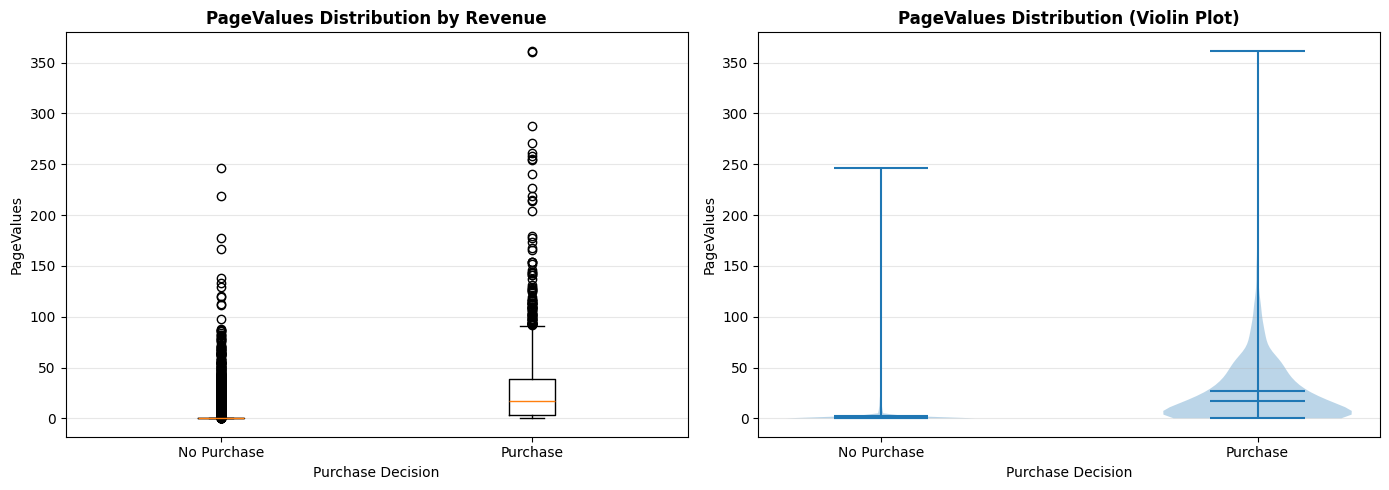

PageValues Statistics by Revenue:

No Purchase Group:
  Mean: 2.00
  Median: 0.00
  Non-zero count: 1192 (11.6%)

Purchase Group:
  Mean: 27.26
  Median: 16.76
  Non-zero count: 1538 (80.6%)


In [34]:
# compare PageValues between purchase and no purchase groups
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# boxplot comparison
purchase_data = df_clean[df_clean['Revenue'] == True]['PageValues']
no_purchase_data = df_clean[df_clean['Revenue'] == False]['PageValues']

axes[0].boxplot([no_purchase_data, purchase_data], labels=['No Purchase', 'Purchase'])
axes[0].set_title('PageValues Distribution by Revenue', fontsize=12, fontweight='bold')
axes[0].set_ylabel('PageValues', fontsize=10)
axes[0].set_xlabel('Purchase Decision', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# violin plot for better distribution view
purchase_df = df_clean.copy()
purchase_df['Revenue_Label'] = purchase_df['Revenue'].map({False: 'No Purchase', True: 'Purchase'})
axes[1].violinplot([no_purchase_data, purchase_data], positions=[0, 1], showmeans=True, showmedians=True)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No Purchase', 'Purchase'])
axes[1].set_title('PageValues Distribution (Violin Plot)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('PageValues', fontsize=10)
axes[1].set_xlabel('Purchase Decision', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# statistical summary
print("PageValues Statistics by Revenue:\n")
print("No Purchase Group:")
print(f"  Mean: {no_purchase_data.mean():.2f}")
print(f"  Median: {no_purchase_data.median():.2f}")
print(f"  Non-zero count: {(no_purchase_data > 0).sum()} ({(no_purchase_data > 0).sum() / len(no_purchase_data) * 100:.1f}%)")

print("\nPurchase Group:")
print(f"  Mean: {purchase_data.mean():.2f}")
print(f"  Median: {purchase_data.median():.2f}")
print(f"  Non-zero count: {(purchase_data > 0).sum()} ({(purchase_data > 0).sum() / len(purchase_data) * 100:.1f}%)")

**KEY FINDING:** PageValues shows a dramatic difference between purchase and no-purchase groups. The purchase group has a mean PageValues of 27.26 (13.6x higher than no-purchase at 2.00) and a median of 16.76 (compared to 0 for no-purchase). Most importantly, 80.6% of purchases have non-zero PageValues, while only 11.6% of non-purchases do. This confirms PageValues is likely our strongest predictor - it directly measures the value of pages visited before transaction, making it an excellent indicator of purchase intent. This feature will be critical for our classification model.


##### **Revenue vs ProductRelated Features**

Product-related pages are where users view items for purchase. We expect users who make purchases to visit more product pages and spend more time browsing products.


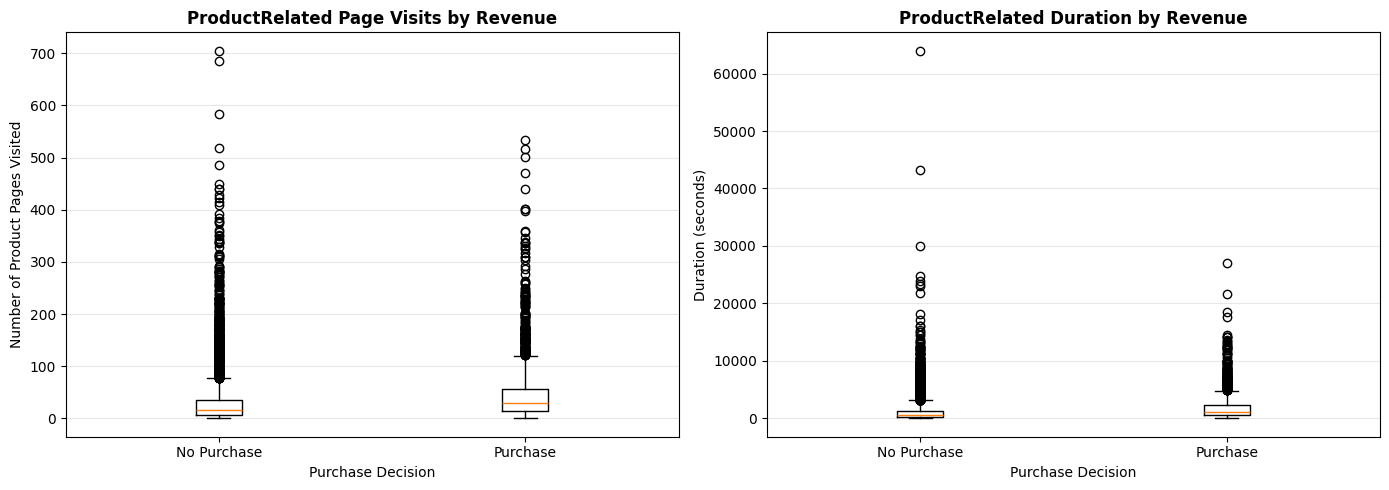

ProductRelated Page Visits by Revenue:

No Purchase - Mean: 29.05, Median: 16.00
Purchase - Mean: 48.21, Median: 29.00
Difference: 19.16 pages (66.0% increase)


ProductRelated Duration by Revenue:

No Purchase - Mean: 1082.98s, Median: 526.00s
Purchase - Mean: 1876.21s, Median: 1109.91s
Difference: 793.23 seconds (73.2% increase)


In [35]:
# compare ProductRelated features between purchase and no purchase groups
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ProductRelated page visits
pr_purchase = df_clean[df_clean['Revenue'] == True]['ProductRelated']
pr_no_purchase = df_clean[df_clean['Revenue'] == False]['ProductRelated']

axes[0].boxplot([pr_no_purchase, pr_purchase], labels=['No Purchase', 'Purchase'])
axes[0].set_title('ProductRelated Page Visits by Revenue', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Product Pages Visited', fontsize=10)
axes[0].set_xlabel('Purchase Decision', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# ProductRelated Duration
prd_purchase = df_clean[df_clean['Revenue'] == True]['ProductRelated_Duration']
prd_no_purchase = df_clean[df_clean['Revenue'] == False]['ProductRelated_Duration']

axes[1].boxplot([prd_no_purchase, prd_purchase], labels=['No Purchase', 'Purchase'])
axes[1].set_title('ProductRelated Duration by Revenue', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Duration (seconds)', fontsize=10)
axes[1].set_xlabel('Purchase Decision', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# statistical comparison
print("ProductRelated Page Visits by Revenue:\n")
print(f"No Purchase - Mean: {pr_no_purchase.mean():.2f}, Median: {pr_no_purchase.median():.2f}")
print(f"Purchase - Mean: {pr_purchase.mean():.2f}, Median: {pr_purchase.median():.2f}")
print(f"Difference: {pr_purchase.mean() - pr_no_purchase.mean():.2f} pages ({((pr_purchase.mean() / pr_no_purchase.mean() - 1) * 100):.1f}% increase)")

print("\n" + "="*60 + "\n")

print("ProductRelated Duration by Revenue:\n")
print(f"No Purchase - Mean: {prd_no_purchase.mean():.2f}s, Median: {prd_no_purchase.median():.2f}s")
print(f"Purchase - Mean: {prd_purchase.mean():.2f}s, Median: {prd_purchase.median():.2f}s")
print(f"Difference: {prd_purchase.mean() - prd_no_purchase.mean():.2f} seconds ({((prd_purchase.mean() / prd_no_purchase.mean() - 1) * 100):.1f}% increase)")

**KEY FINDING:** Purchasers show significantly higher engagement with product pages. They visit 66% more product pages (48.2 vs 29.1 pages) and spend 73.2% more time browsing products (1876s vs 1083s, roughly 31 minutes vs 18 minutes). The boxplots show clear separation between the two groups, though with substantial overlap and outliers. This indicates that while product browsing behavior is predictive of purchases, it's not as definitive as PageValues. Users who spend more time exploring products are more likely to purchase, but the relationship is not absolute.


##### **Revenue vs Engagement Metrics**

BounceRates and ExitRates measure user engagement quality. We expect purchasers to have lower bounce and exit rates, indicating better engagement with the site.


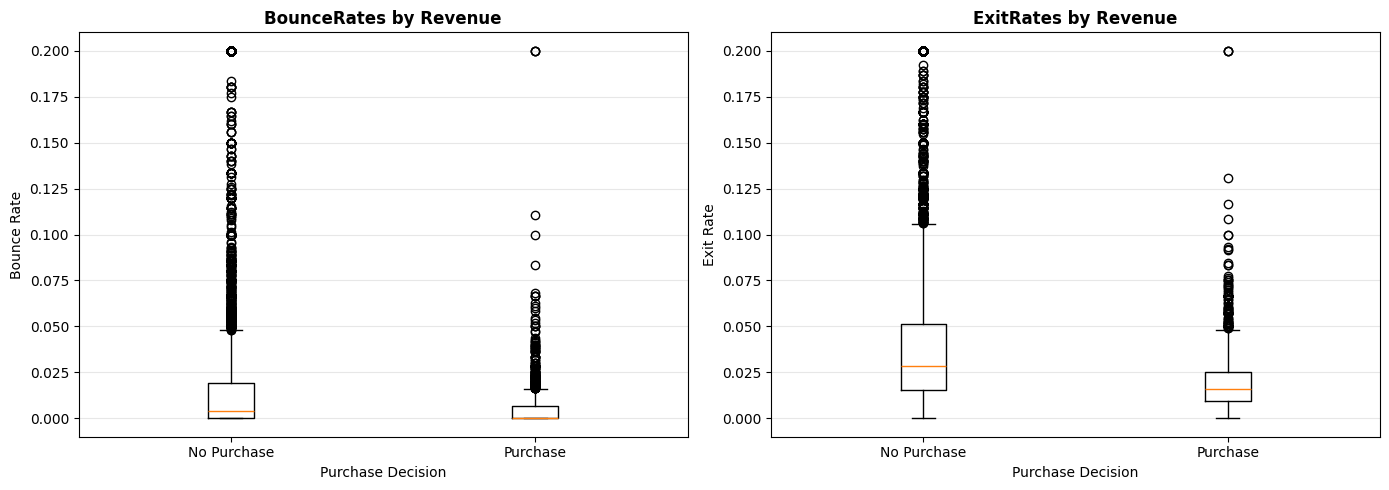

BounceRates by Revenue:

No Purchase - Mean: 0.0232, Median: 0.0039
Purchase - Mean: 0.0051, Median: 0.0000
Difference: 0.0181 (No Purchase is 353.3% higher)


ExitRates by Revenue:

No Purchase - Mean: 0.0455, Median: 0.0284
Purchase - Mean: 0.0196, Median: 0.0160
Difference: 0.0260 (No Purchase is 132.8% higher)


In [36]:
# compare engagement metrics between purchase and no purchase groups
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BounceRates
br_purchase = df_clean[df_clean['Revenue'] == True]['BounceRates']
br_no_purchase = df_clean[df_clean['Revenue'] == False]['BounceRates']

axes[0].boxplot([br_no_purchase, br_purchase], labels=['No Purchase', 'Purchase'])
axes[0].set_title('BounceRates by Revenue', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Bounce Rate', fontsize=10)
axes[0].set_xlabel('Purchase Decision', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# ExitRates
er_purchase = df_clean[df_clean['Revenue'] == True]['ExitRates']
er_no_purchase = df_clean[df_clean['Revenue'] == False]['ExitRates']

axes[1].boxplot([er_no_purchase, er_purchase], labels=['No Purchase', 'Purchase'])
axes[1].set_title('ExitRates by Revenue', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Exit Rate', fontsize=10)
axes[1].set_xlabel('Purchase Decision', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# statistical comparison
print("BounceRates by Revenue:\n")
print(f"No Purchase - Mean: {br_no_purchase.mean():.4f}, Median: {br_no_purchase.median():.4f}")
print(f"Purchase - Mean: {br_purchase.mean():.4f}, Median: {br_purchase.median():.4f}")
print(f"Difference: {br_no_purchase.mean() - br_purchase.mean():.4f} (No Purchase is {((br_no_purchase.mean() / br_purchase.mean() - 1) * 100):.1f}% higher)")

print("\n" + "="*60 + "\n")

print("ExitRates by Revenue:\n")
print(f"No Purchase - Mean: {er_no_purchase.mean():.4f}, Median: {er_no_purchase.median():.4f}")
print(f"Purchase - Mean: {er_purchase.mean():.4f}, Median: {er_purchase.median():.4f}")
print(f"Difference: {er_no_purchase.mean() - er_purchase.mean():.4f} (No Purchase is {((er_no_purchase.mean() / er_purchase.mean() - 1) * 100):.1f}% higher)")

**KEY FINDING:** The engagement metrics strongly differentiate purchasers from non-purchasers. Purchasers have dramatically lower BounceRates (0.0051 vs 0.0232, which is 353.3% lower) with a median of 0, meaning most purchasers engage with multiple pages rather than bouncing. Similarly, ExitRates are 132.8% lower for purchasers (0.0196 vs 0.0455). These metrics confirm that sustained engagement is a strong indicator of purchase intent. Users who bounce or exit quickly are much less likely to complete a purchase, making these valuable features for our classification model.


##### **Revenue vs Temporal Patterns**

We now examine whether purchase rates vary by time of visit. From our univariate analysis, we found strong seasonality in traffic (May and November peaks) and more weekday than weekend sessions. We want to see if conversion rates also differ across these temporal dimensions.


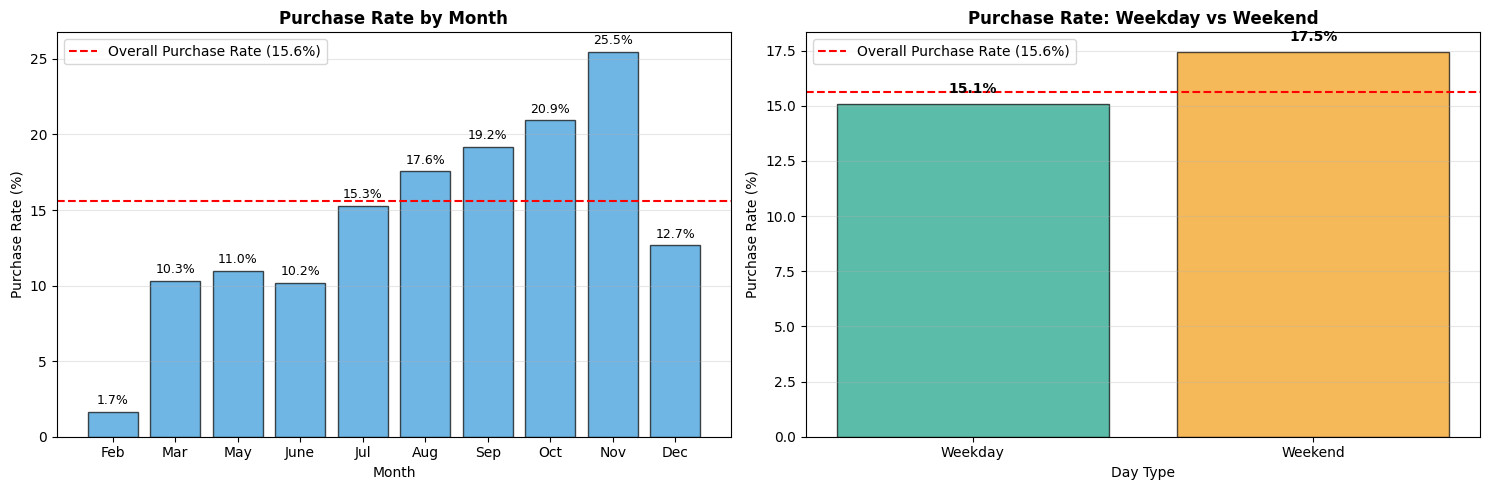

Purchase Rate by Month:

Feb   :  1.66% (   3 purchases /  181 sessions)
Mar   : 10.32% ( 192 purchases / 1860 sessions)
May   : 10.96% ( 365 purchases / 3329 sessions)
June  : 10.18% (  29 purchases /  285 sessions)
Jul   : 15.28% (  66 purchases /  432 sessions)
Aug   : 17.55% (  76 purchases /  433 sessions)
Sep   : 19.20% (  86 purchases /  448 sessions)
Oct   : 20.95% ( 115 purchases /  549 sessions)
Nov   : 25.49% ( 760 purchases / 2982 sessions)
Dec   : 12.66% ( 216 purchases / 1706 sessions)


Purchase Rate by Weekend:

Weekday: 15.08% (1409 purchases / 9346 sessions)
Weekend: 17.45% (499 purchases / 2859 sessions)


In [37]:
# calculate purchase rates by Month and Weekend
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# purchase rate by Month
month_order = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_revenue = df_clean.groupby('Month')['Revenue'].agg(['sum', 'count'])
month_revenue['purchase_rate'] = (month_revenue['sum'] / month_revenue['count']) * 100
month_revenue = month_revenue.reindex(month_order)

axes[0].bar(month_revenue.index, month_revenue['purchase_rate'], color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title('Purchase Rate by Month', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Month', fontsize=10)
axes[0].set_ylabel('Purchase Rate (%)', fontsize=10)
axes[0].axhline(y=15.6, color='red', linestyle='--', label='Overall Purchase Rate (15.6%)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# add value labels
for i, v in enumerate(month_revenue['purchase_rate']):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

# purchase rate by Weekend
weekend_revenue = df_clean.groupby('Weekend')['Revenue'].agg(['sum', 'count'])
weekend_revenue['purchase_rate'] = (weekend_revenue['sum'] / weekend_revenue['count']) * 100

axes[1].bar(['Weekday', 'Weekend'], weekend_revenue['purchase_rate'].values, 
            color=['#16a085', '#f39c12'], edgecolor='black', alpha=0.7)
axes[1].set_title('Purchase Rate: Weekday vs Weekend', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Day Type', fontsize=10)
axes[1].set_ylabel('Purchase Rate (%)', fontsize=10)
axes[1].axhline(y=15.6, color='red', linestyle='--', label='Overall Purchase Rate (15.6%)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# add value labels
for i, v in enumerate(weekend_revenue['purchase_rate'].values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# detailed statistics
print("Purchase Rate by Month:\n")
for month in month_order:
    rate = month_revenue.loc[month, 'purchase_rate']
    count = month_revenue.loc[month, 'count']
    purchases = month_revenue.loc[month, 'sum']
    print(f"{month:6s}: {rate:5.2f}% ({int(purchases):4d} purchases / {int(count):4d} sessions)")

print("\n" + "="*60 + "\n")

print("Purchase Rate by Weekend:\n")
print(f"Weekday: {weekend_revenue.loc[False, 'purchase_rate']:.2f}% ({int(weekend_revenue.loc[False, 'sum'])} purchases / {int(weekend_revenue.loc[False, 'count'])} sessions)")
print(f"Weekend: {weekend_revenue.loc[True, 'purchase_rate']:.2f}% ({int(weekend_revenue.loc[True, 'sum'])} purchases / {int(weekend_revenue.loc[True, 'count'])} sessions)")

**KEY FINDING:** Temporal patterns reveal significant variation in purchase behavior. Purchase rates vary dramatically by month, ranging from just 1.7% in February to 25.5% in November. There's a clear upward trend from summer through fall, with July-November all exceeding the overall 15.6% rate. November shows exceptional conversion (25.5%), likely due to holiday shopping and promotional events. This suggests seasonality is an important predictor.

Interestingly, weekend sessions have a slightly higher conversion rate (17.5% vs 15.1%), indicating weekend shoppers may be more purchase-ready than weekday browsers. These temporal features should be included in our classification model as they capture behavioral differences across time periods.


##### **Revenue vs Visitor Characteristics**

Finally, we examine how visitor type influences purchase behavior. Our univariate analysis showed 85.5% returning visitors and 13.9% new visitors. We want to determine if returning visitors, who are familiar with the site, have higher conversion rates.


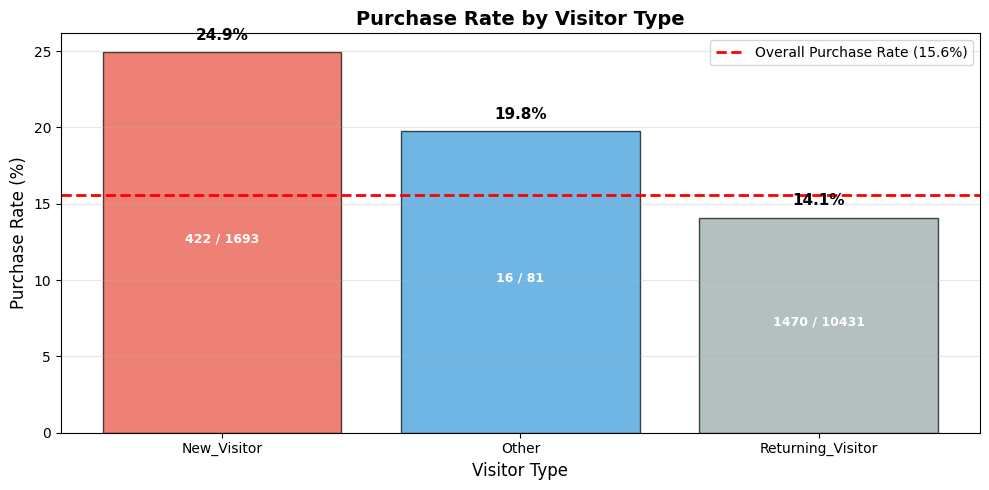

Purchase Rate by Visitor Type:

New_Visitor         : 24.93% ( 422 purchases /  1693 sessions)
Other               : 19.75% (  16 purchases /    81 sessions)
Returning_Visitor   : 14.09% (1470 purchases / 10431 sessions)


Returning visitors convert -10.83 percentage points lower than new visitors
Ratio: 0.57x


In [38]:
# calculate purchase rate by VisitorType
visitor_revenue = df_clean.groupby('VisitorType')['Revenue'].agg(['sum', 'count'])
visitor_revenue['purchase_rate'] = (visitor_revenue['sum'] / visitor_revenue['count']) * 100
visitor_revenue = visitor_revenue.sort_values('purchase_rate', ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(visitor_revenue.index, visitor_revenue['purchase_rate'], 
               color=['#e74c3c', '#3498db', '#95a5a6'], edgecolor='black', alpha=0.7)
plt.title('Purchase Rate by Visitor Type', fontsize=14, fontweight='bold')
plt.xlabel('Visitor Type', fontsize=12)
plt.ylabel('Purchase Rate (%)', fontsize=12)
plt.axhline(y=15.6, color='red', linestyle='--', label='Overall Purchase Rate (15.6%)', linewidth=2)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# add value labels
for i, (idx, row) in enumerate(visitor_revenue.iterrows()):
    plt.text(i, row['purchase_rate'] + 0.8, f"{row['purchase_rate']:.1f}%", 
             ha='center', fontsize=11, fontweight='bold')
    plt.text(i, row['purchase_rate']/2, f"{int(row['sum'])} / {int(row['count'])}", 
             ha='center', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

# detailed statistics
print("Purchase Rate by Visitor Type:\n")
for visitor_type in visitor_revenue.index:
    rate = visitor_revenue.loc[visitor_type, 'purchase_rate']
    count = visitor_revenue.loc[visitor_type, 'count']
    purchases = visitor_revenue.loc[visitor_type, 'sum']
    print(f"{visitor_type:20s}: {rate:5.2f}% ({int(purchases):4d} purchases / {int(count):5d} sessions)")

print("\n" + "="*70 + "\n")

# compare returning vs new (excluding "Other" due to small sample)
returning_rate = visitor_revenue.loc['Returning_Visitor', 'purchase_rate']
new_rate = visitor_revenue.loc['New_Visitor', 'purchase_rate']
print(f"Returning visitors convert {returning_rate - new_rate:.2f} percentage points {'higher' if returning_rate > new_rate else 'lower'} than new visitors")
print(f"Ratio: {returning_rate / new_rate:.2f}x")

**KEY FINDING:** Contrary to typical e-commerce assumptions, new visitors have a significantly HIGHER purchase rate (24.93%) than returning visitors (14.09%) - a 1.77x difference. This counter-intuitive result suggests several possibilities:

1. **Targeted acquisition**: New visitors may arrive through targeted marketing campaigns with specific purchase intent
2. **Research behavior**: Returning visitors might be comparison shopping or researching across multiple sessions before deciding
3. **Selection bias**: The dataset design (one session per user over 1 year) may capture new visitors at their moment of purchase, while returning visitors include many browse-only sessions
4. **Discount hunting**: Returning visitors might be waiting for promotions

The "Other" category shows 19.75% conversion but with only 81 sessions, making it less reliable. This finding highlights that VisitorType should be included in modeling, though its predictive direction differs from expectations. This also suggests we should examine the interaction between VisitorType and other features like PageValues.


**Summary of Bivariate Analysis:**

From our bivariate analysis, we have identified key predictors of purchase behavior:

**Strong Predictors (Large Effect):**

- **PageValues**: 13.6x higher mean for purchasers; 80.6% of purchases have non-zero PageValues
- **BounceRates**: 353% lower for purchasers; strong engagement indicator
- **ExitRates**: 133% lower for purchasers; confirms engagement importance

**Moderate Predictors (Medium Effect):**

- **ProductRelated features**: 66-73% higher for purchasers; more browsing = higher purchase likelihood
- **Month**: 1.7% to 25.5% range; November peak suggests strong seasonality effect
- **VisitorType**: Unexpected pattern with new visitors converting 1.77x better

**Weak Predictors (Small Effect):**

- **Weekend**: Small difference (17.5% vs 15.1%); weekend shoppers slightly more likely to purchase

These insights will directly inform our feature engineering and model building in the next phase.


#### **Correlation Analysis**

Correlation analysis helps us understand relationships between numerical features and identify potential multicollinearity issues. This is crucial for feature selection and model building.


**Correlation Heatmap**

We examine correlations between all numerical features to identify redundant features (high correlation indicates similar information) and understand feature relationships.


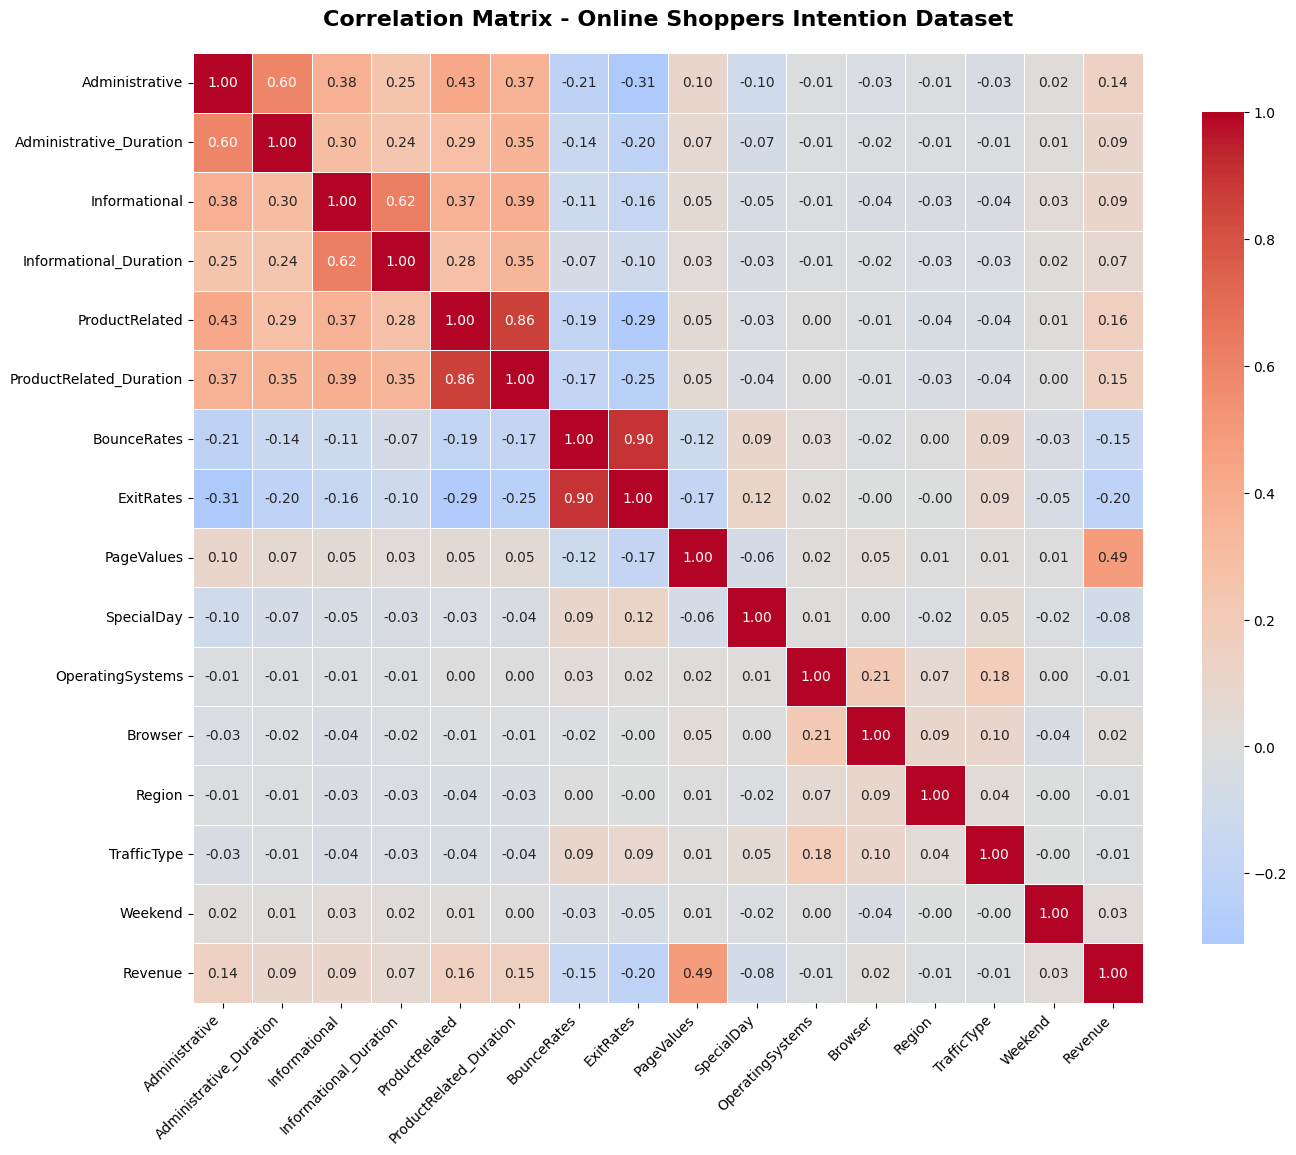

Highly Correlated Feature Pairs (|correlation| > 0.7):

ProductRelated                 <-> ProductRelated_Duration        :  0.860
BounceRates                    <-> ExitRates                      :  0.902


In [39]:
plt.figure(figsize=(14, 12))
correlation_matrix = df_clean.corr(numeric_only=True)
sns.heatmap(correlation_matrix, 
            annot=True,  # Show correlation values
            fmt='.2f',   # 2 decimal places
            cmap='coolwarm',  # Red (positive) to Blue (negative)
            center=0,    # Center colormap at 0
            square=True, # Square cells
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Correlation Matrix - Online Shoppers Intention Dataset', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# identify highly correlated pairs (threshold > 0.7)
print("Highly Correlated Feature Pairs (|correlation| > 0.7):\n")
print("="*70)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            feature1 = correlation_matrix.columns[i]
            feature2 = correlation_matrix.columns[j]
            corr_value = correlation_matrix.iloc[i, j]
            high_corr_pairs.append((feature1, feature2, corr_value))
            print(f"{feature1:30s} <-> {feature2:30s} : {corr_value:6.3f}")

if len(high_corr_pairs) == 0:
    print("No feature pairs with correlation > 0.7 found.")

**Key Correlation Insights:**

The heatmap reveals two important highly correlated pairs that indicate multicollinearity:

1. **ProductRelated & ProductRelated_Duration (0.86)**: Strong positive correlation indicates that users who visit more product pages naturally spend more time browsing. While both are predictive of purchases, they contain overlapping information.

2. **BounceRates & ExitRates (0.90)**: Very high correlation shows these metrics measure similar exit behavior. This is the strongest multicollinearity in our dataset and suggests we should consider keeping only one of these features in our final model.

**Positive Findings:**

- Most features show low to moderate correlations (< 0.7), indicating they provide unique information
- System features (OperatingSystems, Browser, Region, TrafficType) have very low correlations with other features, suggesting they capture independent user characteristics
- PageValues shows relatively low correlation with most features except Revenue, confirming it provides unique predictive value

**Implications for Modeling:**
To avoid multicollinearity issues, we may need to drop one feature from each highly correlated pair during feature selection. This will be addressed in the feature engineering phase.


**Feature Correlation with Target (Revenue)**

Now we examine which features have the strongest correlation with our target variable. This helps us rank features by their potential predictive power for classification.


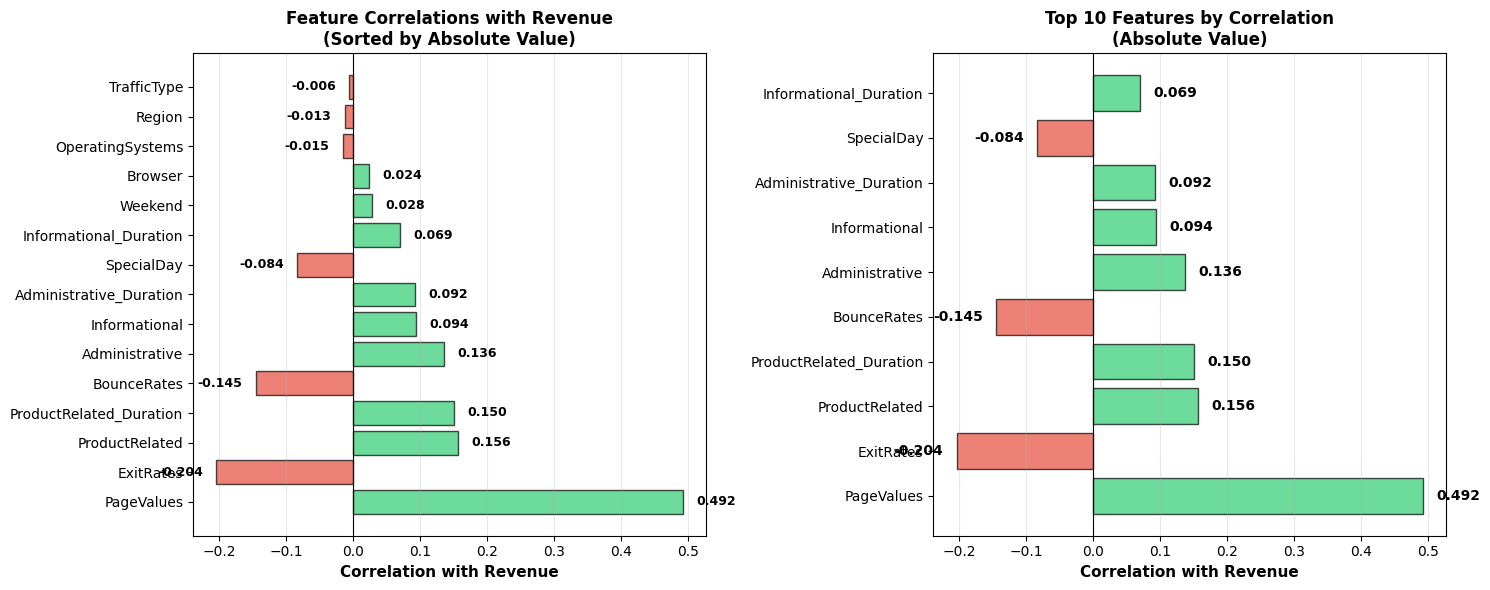

Feature Correlation with Revenue (Ranked by Absolute Value):

Rank   Feature                         Correlation Direction      
1      PageValues                           0.4919   Positive       
2      ExitRates                           -0.2043   Negative       
3      ProductRelated                       0.1560   Positive       
4      ProductRelated_Duration              0.1501   Positive       
5      BounceRates                         -0.1451   Negative       
6      Administrative                       0.1363   Positive       
7      Informational                        0.0936   Positive       
8      Administrative_Duration              0.0918   Positive       
9      SpecialDay                          -0.0836   Negative       
10     Informational_Duration               0.0694   Positive       
11     Weekend                              0.0277   Positive       
12     Browser                              0.0241   Positive       
13     OperatingSystems                    

In [40]:
# extract correlations with Revenue and sort by absolute value
revenue_correlations = correlation_matrix['Revenue'].drop('Revenue').sort_values(key=abs, ascending=False)

# create bar chart
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# plot 1: All correlations sorted by absolute value
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in revenue_correlations.values]
axes[0].barh(range(len(revenue_correlations)), revenue_correlations.values, color=colors, edgecolor='black', alpha=0.7)
axes[0].set_yticks(range(len(revenue_correlations)))
axes[0].set_yticklabels(revenue_correlations.index)
axes[0].set_xlabel('Correlation with Revenue', fontsize=11, fontweight='bold')
axes[0].set_title('Feature Correlations with Revenue\n(Sorted by Absolute Value)', fontsize=12, fontweight='bold')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[0].grid(axis='x', alpha=0.3)

# add value labels
for i, v in enumerate(revenue_correlations.values):
    axes[0].text(v + (0.02 if v > 0 else -0.02), i, f'{v:.3f}', 
                va='center', ha='left' if v > 0 else 'right', fontsize=9, fontweight='bold')

# plot 2: Top 10 features only
top_10 = revenue_correlations.head(10)
colors_top10 = ['#e74c3c' if x < 0 else '#2ecc71' for x in top_10.values]
axes[1].barh(range(len(top_10)), top_10.values, color=colors_top10, edgecolor='black', alpha=0.7)
axes[1].set_yticks(range(len(top_10)))
axes[1].set_yticklabels(top_10.index)
axes[1].set_xlabel('Correlation with Revenue', fontsize=11, fontweight='bold')
axes[1].set_title('Top 10 Features by Correlation\n(Absolute Value)', fontsize=12, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(axis='x', alpha=0.3)

# add value labels
for i, v in enumerate(top_10.values):
    axes[1].text(v + (0.02 if v > 0 else -0.02), i, f'{v:.3f}', 
                va='center', ha='left' if v > 0 else 'right', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# detailed ranking
print("Feature Correlation with Revenue (Ranked by Absolute Value):\n")
print("="*70)
print(f"{'Rank':<6} {'Feature':<30} {'Correlation':>12} {'Direction':<15}")
print("="*70)

for rank, (feature, corr) in enumerate(revenue_correlations.items(), 1):
    direction = "Positive" if corr > 0 else "Negative"
    print(f"{rank:<6} {feature:<30} {corr:>12.4f}   {direction:<15}")

print("\n" + "="*70)
print("\nInterpretation:")
print("- Positive correlation: Higher feature value → Higher purchase likelihood")
print("- Negative correlation: Higher feature value → Lower purchase likelihood")

**Feature Importance Ranking Analysis:**

The correlation analysis confirms our bivariate findings and provides clear feature importance ranking:

**Tier 1 - Strong Predictors (|correlation| > 0.15):**

- **PageValues (0.49)**: By far the strongest predictor. This validates our bivariate analysis where 80.6% of purchases had non-zero PageValues. This feature should be prioritized in all models.
- **ExitRates (-0.20)**: Negative correlation confirms that lower exit rates indicate higher purchase likelihood
- **ProductRelated features (0.15-0.16)**: Both page visits and duration show moderate positive correlation

**Tier 2 - Moderate Predictors (0.09 < |correlation| < 0.15):**

- **BounceRates (-0.15)**: Similar to ExitRates, lower bounce indicates better engagement
- **Administrative features (0.09-0.14)**: Weak but present positive relationship
- **Informational features (0.07-0.09)**: Very weak positive relationship

**Tier 3 - Weak/Negligible Predictors (|correlation| < 0.09):**

- **SpecialDay (-0.08)**: Slight negative correlation, contrary to expectations
- **System features** (Browser, OS, Region, TrafficType): All near-zero correlations (< 0.03), suggesting these don't directly predict purchases

**Critical Insights for Feature Engineering:**

1. Focus modeling efforts on Tier 1 features, especially PageValues
2. Resolve multicollinearity by selecting one feature from correlated pairs (ExitRates vs BounceRates, ProductRelated vs ProductRelated_Duration)
3. Consider dropping or transforming Tier 3 features with minimal predictive value
4. Categorical features (Month, VisitorType, Weekend) not shown here but proved important in bivariate analysis - these will be encoded and included


## **Task 2: Feature Engineering**


### **2.1 Feature Engineering Strategy**

Based on our EDA findings, we apply advanced feature engineering to create more informative features. Our approach follows best practices to prevent data leakage and ensure reproducibility:

1. **Data Splitting**: Train (70%) / Validation (15%) / Test (15%) with stratification
2. **Advanced Feature Engineering**: 
   - Log transformation for skewed duration and PageValues features
   - Behavioral metrics (Total_Pages, Avg_Time_Per_Page, Product_Focus_Ratio)
   - Temporal encoding (Is_Peak_Season based on high-conversion months)
   - Remove redundant original features after engineering
3. **Preprocessing Pipeline**: One-hot encoding for categorical, standardization for numerical
4. **Filter-Based Selection (Method 1)**: Variance Threshold + Correlation Filter
5. **Supervised Selection (Method 2)**: Mutual Information feature importance
6. **Final Feature Set**: Optimized matrix ready for classification models

In [41]:
# import required libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
import numpy as np

# set random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Feature Engineering Pipeline Initialized")
print(f"Random State: {RANDOM_STATE}")
print(f"Starting dataset shape: {df_clean.shape}")

Feature Engineering Pipeline Initialized
Random State: 42
Starting dataset shape: (12205, 18)


### **2.2 Data Splitting (Train / Validation / Test)**

We split the data into three sets with stratification to maintain class balance across all sets. This prevents data leakage and enables proper model validation.

In [42]:
# separate features and target
X = df_clean.drop('Revenue', axis=1)
y = df_clean['Revenue'].astype(int)  # convert boolean to 0/1

# first split: separate test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)

# second split: separate train (70%) and validation (15%) from remaining 85%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=RANDOM_STATE, stratify=y_temp  # 0.176 * 0.85 ≈ 0.15
)

print("Data Split Complete:")
print(f"{'Set':<12} {'Samples':<10} {'% Total':<10} {'Class 0':<10} {'Class 1':<10} {'Balance'}")
print("="*70)
print(f"{'Train':<12} {len(y_train):<10} {len(y_train)/len(y)*100:>6.1f}%    {(y_train==0).sum():<10} {(y_train==1).sum():<10} {(y_train==1).sum()/len(y_train)*100:.1f}%")
print(f"{'Validation':<12} {len(y_val):<10} {len(y_val)/len(y)*100:>6.1f}%    {(y_val==0).sum():<10} {(y_val==1).sum():<10} {(y_val==1).sum()/len(y_val)*100:.1f}%")
print(f"{'Test':<12} {len(y_test):<10} {len(y_test)/len(y)*100:>6.1f}%    {(y_test==0).sum():<10} {(y_test==1).sum():<10} {(y_test==1).sum()/len(y_test)*100:.1f}%")
print(f"{'Total':<12} {len(y):<10} {100.0:>6.1f}%    {(y==0).sum():<10} {(y==1).sum():<10} {(y==1).sum()/len(y)*100:.1f}%")

Data Split Complete:
Set          Samples    % Total    Class 0    Class 1    Balance
Train        8548         70.0%    7211       1337       15.6%
Validation   1826         15.0%    1541       285        15.6%
Test         1831         15.0%    1545       286        15.6%
Total        12205       100.0%    10297      1908       15.6%


### **2.3 Advanced Feature Engineering**

We apply domain-informed transformations to create more informative features and address data skewness. This includes log transformations for skewed variables, behavioral metrics, and temporal patterns.

#### **2.3.1 Log Transformation for Skewed Features**

From EDA, we observed severe right skewness in duration and PageValues features. Log transformation reduces skewness and makes distributions more suitable for modeling.

In [43]:
# apply log transformation to skewed features (fit-transform logic on train only)
skewed_features = ['PageValues', 'Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration']

# transform train set
for col in skewed_features:
    X_train[f'{col}_log'] = np.log1p(X_train[col])
    X_val[f'{col}_log'] = np.log1p(X_val[col])
    X_test[f'{col}_log'] = np.log1p(X_test[col])

print("Log Transformation Applied:")
print("="*70)
print(f"Transformed features: {skewed_features}")
print(f"New features created: {[f'{col}_log' for col in skewed_features]}")
print(f"\nShape after log transformation:")
print(f"  Train: {X_train.shape}")
print(f"  Val:   {X_val.shape}")
print(f"  Test:  {X_test.shape}")

Log Transformation Applied:
Transformed features: ['PageValues', 'Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration']
New features created: ['PageValues_log', 'Administrative_Duration_log', 'Informational_Duration_log', 'ProductRelated_Duration_log']

Shape after log transformation:
  Train: (8548, 21)
  Val:   (1826, 21)
  Test:  (1831, 21)


#### **2.3.2 Behavioral Feature Engineering**

We create interaction features that capture user browsing behavior patterns, such as total engagement, time efficiency, and product focus.

In [44]:
# create behavioral features on train, val, test
def create_behavioral_features(df):
    """Create engineered behavioral features"""
    df = df.copy()
    
    # total page views across all categories
    df['Total_Pages'] = df['Administrative'] + df['Informational'] + df['ProductRelated']
    
    # total duration (using log-transformed features)
    df['Total_Duration_log'] = (df['Administrative_Duration_log'] + 
                                 df['Informational_Duration_log'] + 
                                 df['ProductRelated_Duration_log'])
    
    # average time per page (efficiency metric)
    df['Avg_Time_Per_Page_log'] = df['Total_Duration_log'] / (df['Total_Pages'] + 1)
    
    # product focus ratio (how much user focuses on product pages)
    df['Product_Focus_Ratio'] = df['ProductRelated'] / (df['Total_Pages'] + 1)
    
    return df

# apply to all sets
X_train = create_behavioral_features(X_train)
X_val = create_behavioral_features(X_val)
X_test = create_behavioral_features(X_test)

print("Behavioral Features Created:")
print("="*70)
print("  - Total_Pages: Sum of all page visits")
print("  - Total_Duration_log: Sum of log-transformed durations")
print("  - Avg_Time_Per_Page_log: Average time spent per page")
print("  - Product_Focus_Ratio: Proportion of product page visits")
print(f"\nShape after behavioral engineering:")
print(f"  Train: {X_train.shape}")
print(f"  Val:   {X_val.shape}")
print(f"  Test:  {X_test.shape}")

Behavioral Features Created:
  - Total_Pages: Sum of all page visits
  - Total_Duration_log: Sum of log-transformed durations
  - Avg_Time_Per_Page_log: Average time spent per page
  - Product_Focus_Ratio: Proportion of product page visits

Shape after behavioral engineering:
  Train: (8548, 25)
  Val:   (1826, 25)
  Test:  (1831, 25)


#### **2.3.3 Temporal Pattern Encoding**

From bivariate analysis, we found significant purchase rate variation across months. We create a binary feature to identify peak shopping seasons (May, November, December) which showed higher conversion rates.

In [45]:
# create peak season indicator based on EDA insights
peak_months = ['May', 'Nov', 'Dec']

X_train['Is_Peak_Season'] = X_train['Month'].isin(peak_months).astype(int)
X_val['Is_Peak_Season'] = X_val['Month'].isin(peak_months).astype(int)
X_test['Is_Peak_Season'] = X_test['Month'].isin(peak_months).astype(int)

print("Temporal Features Created:")
print("="*70)
print(f"Peak season months: {peak_months}")
print(f"\nPeak season distribution (Train):")
print(f"  Non-peak: {(X_train['Is_Peak_Season']==0).sum()} ({(X_train['Is_Peak_Season']==0).sum()/len(X_train)*100:.1f}%)")
print(f"  Peak:     {(X_train['Is_Peak_Season']==1).sum()} ({(X_train['Is_Peak_Season']==1).sum()/len(X_train)*100:.1f}%)")
print(f"\nShape after temporal encoding:")
print(f"  Train: {X_train.shape}")
print(f"  Val:   {X_val.shape}")
print(f"  Test:  {X_test.shape}")

Temporal Features Created:
Peak season months: ['May', 'Nov', 'Dec']

Peak season distribution (Train):
  Non-peak: 2921 (34.2%)
  Peak:     5627 (65.8%)

Shape after temporal encoding:
  Train: (8548, 26)
  Val:   (1826, 26)
  Test:  (1831, 26)


#### **2.3.4 Redundant Feature Removal**

After creating engineered features, we remove the original features that were used to create them, keeping only the transformed versions to reduce redundancy and dimensionality.

In [46]:
# remove redundant features after engineering
redundant_features = [
    # original skewed features (replaced by log versions)
    'PageValues', 'Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration',
    
    # individual page counts (captured by Total_Pages and Product_Focus_Ratio)
    'Administrative', 'Informational',
    
    # intermediate feature (already incorporated into Avg_Time_Per_Page_log)
    'Total_Duration_log'
]

# remove from all sets
X_train = X_train.drop(columns=[c for c in redundant_features if c in X_train.columns])
X_val = X_val.drop(columns=[c for c in redundant_features if c in X_val.columns])
X_test = X_test.drop(columns=[c for c in redundant_features if c in X_test.columns])

print("Redundant Features Removed:")
print("="*70)
print(f"Removed: {len(redundant_features)} features")
for feat in redundant_features:
    print(f"  - {feat}")
print(f"\nFinal shape after feature engineering:")
print(f"  Train: {X_train.shape}")
print(f"  Val:   {X_val.shape}")
print(f"  Test:  {X_test.shape}")
print(f"\nRetained features: {list(X_train.columns)}")

Redundant Features Removed:
Removed: 7 features
  - PageValues
  - Administrative_Duration
  - Informational_Duration
  - ProductRelated_Duration
  - Administrative
  - Informational
  - Total_Duration_log

Final shape after feature engineering:
  Train: (8548, 19)
  Val:   (1826, 19)
  Test:  (1831, 19)

Retained features: ['ProductRelated', 'BounceRates', 'ExitRates', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'PageValues_log', 'Administrative_Duration_log', 'Informational_Duration_log', 'ProductRelated_Duration_log', 'Total_Pages', 'Avg_Time_Per_Page_log', 'Product_Focus_Ratio', 'Is_Peak_Season']


### **2.4 Preprocessing Pipeline (Encoding + Scaling)**

Now we apply categorical encoding and numerical scaling to prepare the engineered features for modeling. The pipeline ensures consistent transformations across train/val/test sets.

In [47]:
# identify column types after feature engineering
categorical_cols = X_train.select_dtypes(include=['object', 'bool']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print("Feature Types (After Engineering):")
print("="*70)
print(f"Categorical ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical ({len(numerical_cols)}): {numerical_cols}")

# create preprocessing pipeline with encoding and scaling
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ],
    remainder='drop'
)

# fit on training data only, transform all sets
X_train_transformed = preprocessor.fit_transform(X_train)
X_val_transformed = preprocessor.transform(X_val)
X_test_transformed = preprocessor.transform(X_test)

# get feature names after transformation
num_feature_names = numerical_cols
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
feature_names = num_feature_names + cat_feature_names

print(f"\nPreprocessing Complete:")
print(f"Features before encoding: {X_train.shape[1]}")
print(f"Features after encoding: {X_train_transformed.shape[1]}")
print(f"Transformation: {len(numerical_cols)} numeric + {len(categorical_cols)} categorical → {len(feature_names)} total")

Feature Types (After Engineering):
Categorical (3): ['Month', 'VisitorType', 'Weekend']
Numerical (16): ['ProductRelated', 'BounceRates', 'ExitRates', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'PageValues_log', 'Administrative_Duration_log', 'Informational_Duration_log', 'ProductRelated_Duration_log', 'Total_Pages', 'Avg_Time_Per_Page_log', 'Product_Focus_Ratio', 'Is_Peak_Season']

Preprocessing Complete:
Features before encoding: 19
Features after encoding: 28
Transformation: 16 numeric + 3 categorical → 28 total


### **2.5 Feature Selection Method 1: Filter-Based (Variance + Correlation)**

This method serves as a baseline for both classification and clustering tasks. It removes useless features (near-constant) and redundant features (highly correlated), reducing dimensionality while preserving information.

#### **2.5.1 Variance Threshold**

Removes near-constant features with variance below threshold (0.01). These features provide minimal information for distinguishing between different sessions.

In [48]:
# apply variance threshold (default threshold=0.0 removes constant features)
# using stricter threshold for encoded features
variance_selector = VarianceThreshold(threshold=0.01)

# fit on training data only
X_train_var = variance_selector.fit_transform(X_train_transformed)
X_val_var = variance_selector.transform(X_val_transformed)
X_test_var = variance_selector.transform(X_test_transformed)

# get selected feature names
selected_features_mask = variance_selector.get_support()
selected_feature_names = [feature_names[i] for i, selected in enumerate(selected_features_mask) if selected]

# calculate variance for each feature
feature_variances = variance_selector.variances_

print("Variance Threshold Feature Selection:")
print("="*70)
print(f"Threshold: {variance_selector.threshold}")
print(f"Features before: {X_train_transformed.shape[1]}")
print(f"Features after: {X_train_var.shape[1]}")
print(f"Features removed: {X_train_transformed.shape[1] - X_train_var.shape[1]}")

# show removed features if any
removed_features = [feature_names[i] for i, selected in enumerate(selected_features_mask) if not selected]
if removed_features:
    print(f"\nRemoved features ({len(removed_features)}):")
    for feat in removed_features:
        idx = feature_names.index(feat)
        print(f"  - {feat}: variance = {feature_variances[idx]:.6f}")

Variance Threshold Feature Selection:
Threshold: 0.01
Features before: 28
Features after: 27
Features removed: 1

Removed features (1):
  - VisitorType_Other: variance = 0.006855


#### **2.5.2 Correlation Filter (Redundancy Removal)**

The correlation filter removes redundant features by identifying pairs with high correlation (above threshold). When two features are highly correlated, they provide similar information, so we keep only one to reduce multicollinearity.

In [49]:
# compute correlation matrix on training data
correlation_matrix = pd.DataFrame(X_train_var, columns=selected_feature_names).corr().abs()

# find highly correlated pairs (threshold = 0.90)
corr_threshold = 0.90
upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

# identify features to drop
features_to_drop = []
high_corr_pairs = []

for column in upper_triangle.columns:
    correlated_features = upper_triangle[column][upper_triangle[column] > corr_threshold]
    if len(correlated_features) > 0:
        for feat, corr_val in correlated_features.items():
            high_corr_pairs.append((column, feat, corr_val))
            if column not in features_to_drop:
                features_to_drop.append(column)

print("Correlation Filter (Threshold = {:.2f}):".format(corr_threshold))
print("="*70)
print(f"Features before correlation filter: {len(selected_feature_names)}")
print(f"Highly correlated pairs found: {len(high_corr_pairs)}")
print(f"Features to remove: {len(features_to_drop)}")

if high_corr_pairs:
    print("\nHighly Correlated Feature Pairs:")
    for feat1, feat2, corr_val in high_corr_pairs:
        print(f"  {feat1} <-> {feat2}: {corr_val:.4f}")
else:
    print("\nNo highly correlated feature pairs found above threshold.")

# drop correlated features
features_to_keep = [f for f in selected_feature_names if f not in features_to_drop]
feature_indices_to_keep = [i for i, f in enumerate(selected_feature_names) if f in features_to_keep]

X_train_filtered = X_train_var[:, feature_indices_to_keep]
X_val_filtered = X_val_var[:, feature_indices_to_keep]
X_test_filtered = X_test_var[:, feature_indices_to_keep]

print(f"\nFeatures after correlation filter: {X_train_filtered.shape[1]}")
print(f"Total features removed: {X_train_var.shape[1] - X_train_filtered.shape[1]}")

Correlation Filter (Threshold = 0.90):
Features before correlation filter: 27
Highly correlated pairs found: 1
Features to remove: 1

Highly Correlated Feature Pairs:
  Total_Pages <-> ProductRelated: 0.9972

Features after correlation filter: 26
Total features removed: 1


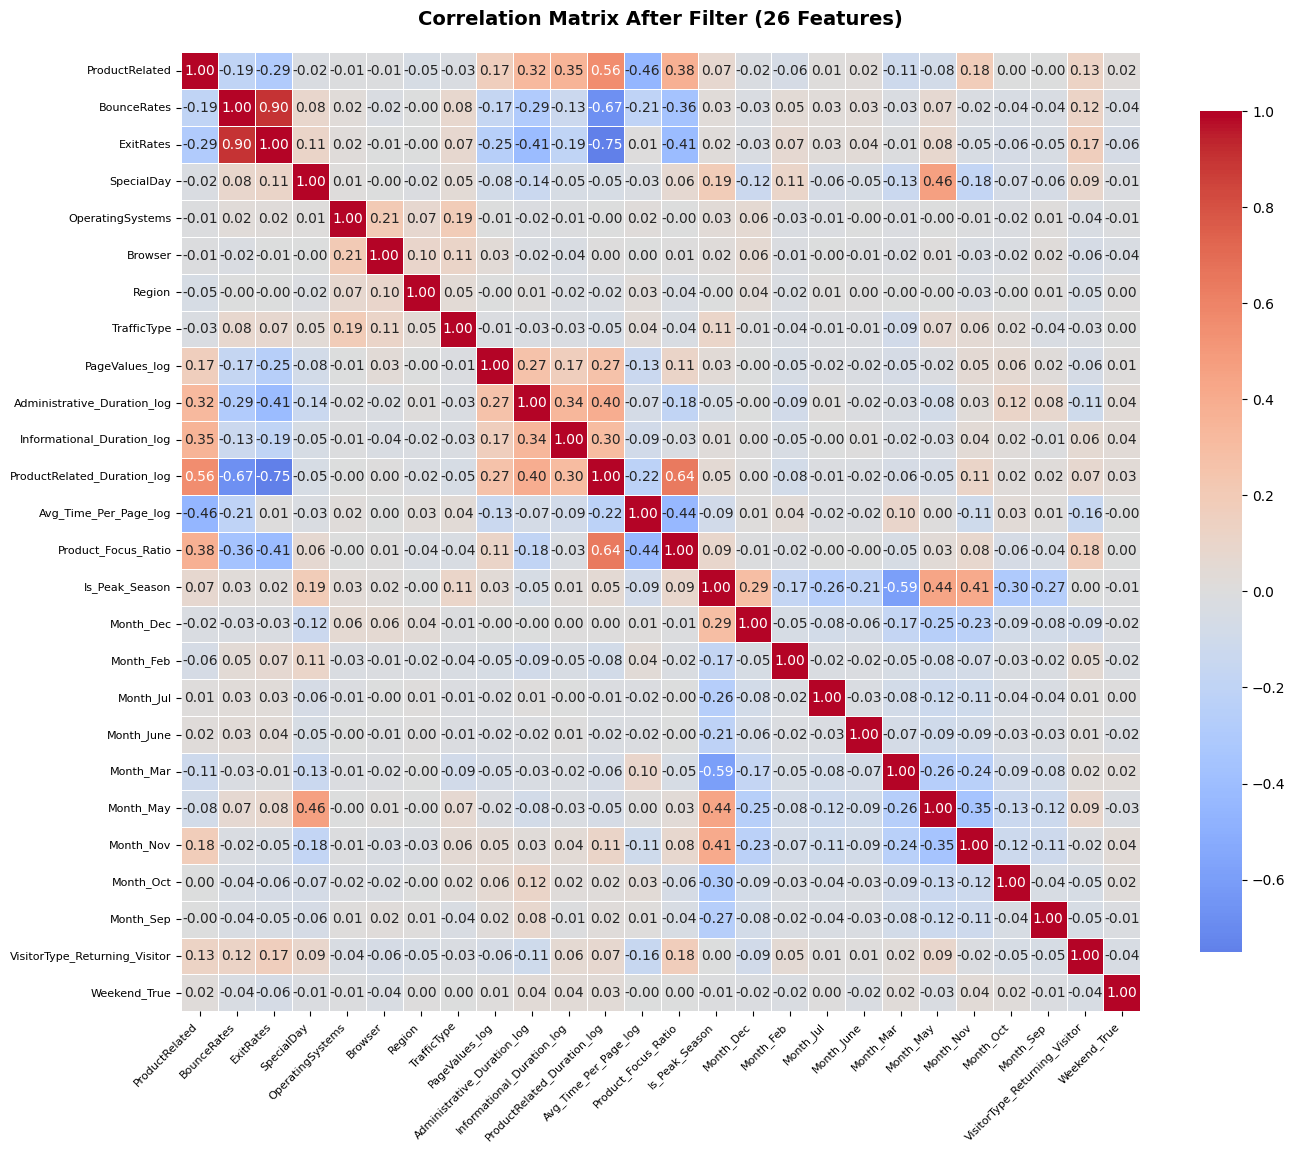


Remaining Feature Correlations (|correlation| > 0.6):
BounceRates                         <-> ExitRates                           :  0.897
BounceRates                         <-> ProductRelated_Duration_log         : -0.673
ExitRates                           <-> ProductRelated_Duration_log         : -0.752
ProductRelated_Duration_log         <-> Product_Focus_Ratio                 :  0.644


In [50]:
# visualize correlation matrix after filtering
plt.figure(figsize=(14, 12))
correlation_matrix_full = pd.DataFrame(X_train_filtered, columns=features_to_keep).corr()
sns.heatmap(correlation_matrix_full, 
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Correlation Matrix After Filter (26 Features)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# show remaining high correlations (threshold > 0.6 for visibility)
print("\nRemaining Feature Correlations (|correlation| > 0.6):")
print("="*70)
high_corr_remaining = []
for i in range(len(correlation_matrix_full.columns)):
    for j in range(i+1, len(correlation_matrix_full.columns)):
        corr_val = correlation_matrix_full.iloc[i, j]
        if abs(corr_val) > 0.6:
            feat1 = correlation_matrix_full.columns[i]
            feat2 = correlation_matrix_full.columns[j]
            high_corr_remaining.append((feat1, feat2, corr_val))
            print(f"{feat1:35s} <-> {feat2:35s} : {corr_val:6.3f}")

if len(high_corr_remaining) == 0:
    print("No feature pairs with |correlation| > 0.6 remaining.")

### **2.6 Classification Feature Selection (Supervised Methods)**

#### **2.6.1 Mutual Information Ranking (Filter Method)**
Mutual Information measures the dependency between each feature and the target variable (Revenue). Unlike correlation, MI captures both linear and non-linear relationships, making it suitable for identifying features that have strong predictive power for purchase prediction.

In [51]:
# compute mutual information scores on training data
mi_scores = mutual_info_classif(X_train_filtered, y_train, random_state=RANDOM_STATE, n_neighbors=5)

# create feature importance dataframe
mi_df = pd.DataFrame({
    'Feature': features_to_keep,
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False)

print("Mutual Information Feature Importance (Top 15):")
print("="*70)
print(mi_df.head(15).to_string(index=False))
print(f"\nTotal features analyzed: {len(features_to_keep)}")
print(f"Mean MI Score: {mi_scores.mean():.4f}")
print(f"Std MI Score: {mi_scores.std():.4f}")

Mutual Information Feature Importance (Top 15):
                    Feature  MI_Score
             PageValues_log  0.165825
                  ExitRates  0.036125
ProductRelated_Duration_log  0.031136
             ProductRelated  0.022080
                BounceRates  0.020983
Administrative_Duration_log  0.017776
        Product_Focus_Ratio  0.015934
                TrafficType  0.015785
      Avg_Time_Per_Page_log  0.013884
                  Month_Nov  0.012249
                 SpecialDay  0.009691
           OperatingSystems  0.005997
                  Month_May  0.004660
                  Month_Dec  0.004358
                     Region  0.003804

Total features analyzed: 26
Mean MI Score: 0.0152
Std MI Score: 0.0317


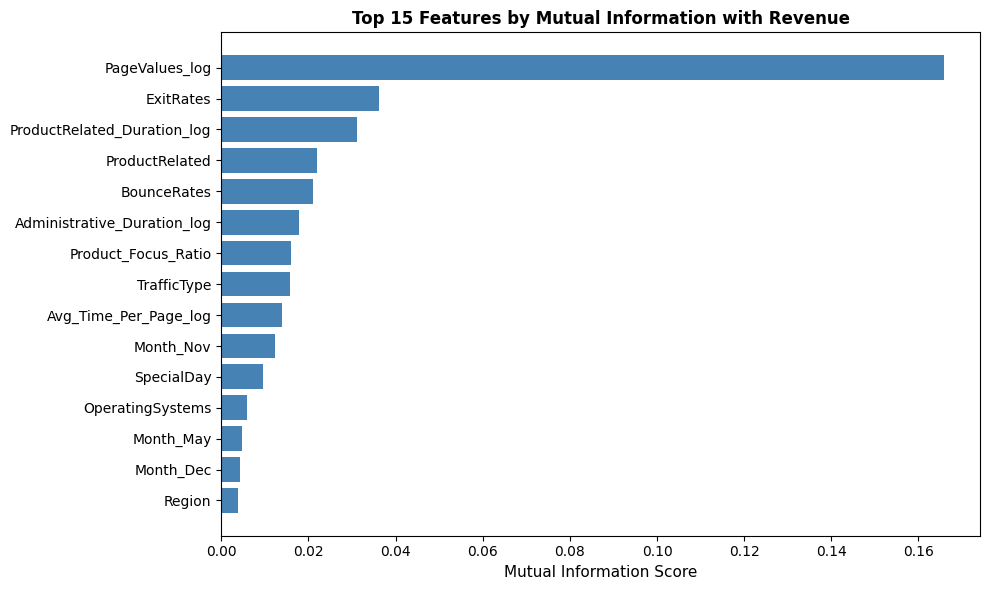

In [52]:
# visualize top features by mutual information
top_n = 15
top_mi_features = mi_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_mi_features)), top_mi_features['MI_Score'], color='steelblue')
plt.yticks(range(len(top_mi_features)), top_mi_features['Feature'])
plt.xlabel('Mutual Information Score', fontsize=11)
plt.title(f'Top {top_n} Features by Mutual Information with Revenue', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Feature Selection Criterion:**

We select the top 12 features based on MI scores for the following reasons:
1. **Clear score drop-off:** After rank 12, MI scores drop below 0.006 (50% lower than rank 11)
2. **Dimensionality reduction:** 12 features provide strong predictive power while maintaining model interpretability
3. **Generalizability:** A moderate feature set works better across different classification algorithms (Logistic Regression, SVM, Random Forest)
4. **Above-mean performance:** Top 12 features all score above the mean MI (0.0152)

In [53]:
# Select top 12 features based on MI scores
top_feature_names = mi_df.head(12)['Feature'].tolist()
mi_scores_sorted = mi_df.head(12)['MI_Score'].tolist()

print("\n" + "="*70)
print("MI METHOD: Top 12 features selected")
print("="*70)
for i, (feat, score) in enumerate(zip(top_feature_names, mi_scores_sorted), 1):
    print(f"  {i:2d}. {feat:35s} (MI: {score:.4f})")
print("="*70)


MI METHOD: Top 12 features selected
   1. PageValues_log                      (MI: 0.1658)
   2. ExitRates                           (MI: 0.0361)
   3. ProductRelated_Duration_log         (MI: 0.0311)
   4. ProductRelated                      (MI: 0.0221)
   5. BounceRates                         (MI: 0.0210)
   6. Administrative_Duration_log         (MI: 0.0178)
   7. Product_Focus_Ratio                 (MI: 0.0159)
   8. TrafficType                         (MI: 0.0158)
   9. Avg_Time_Per_Page_log               (MI: 0.0139)
  10. Month_Nov                           (MI: 0.0122)
  11. SpecialDay                          (MI: 0.0097)
  12. OperatingSystems                    (MI: 0.0060)


#### **2.6.2 Recursive Feature Elimination with CV - Validation (Wrapper Method)**

To validate our MI-based feature selection, we apply **RFECV (Recursive Feature Elimination with Cross-Validation)** using Random Forest as the base estimator. 

**Key differences from MI:**
- RFECV is a wrapper method that considers feature interactions
- Uses cross-validation to find the optimal number of features
- Model-based (not model-agnostic like MI)

**Purpose:** Independent validation of feature selection. RFECV will determine its own optimal feature count, allowing us to assess whether 12 features is appropriate.

In [54]:
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier

# Get feature names (from correlation filter step)
feature_names_filtered = features_to_keep

# RFECV with Random Forest
rf_estimator = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

print("Running RFECV with 5-fold cross-validation...")
print("(This may take 1-2 minutes)\n")

rfecv_selector = RFECV(
    estimator=rf_estimator,
    step=1,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

rfecv_selector.fit(X_train_filtered, y_train)

# Get results
optimal_features = rfecv_selector.n_features_
rfecv_feature_names = [feature_names_filtered[i] 
                       for i, selected in enumerate(rfecv_selector.support_) 
                       if selected]

print("="*70)
print("RFECV RESULTS")
print("="*70)
print(f"Optimal number of features (by CV): {optimal_features}")
print(f"Best CV score (AUC): {rfecv_selector.cv_results_['mean_test_score'].max():.4f}")

print(f"\nRFECV-selected features ({optimal_features} total):")
for idx, feat in enumerate(rfecv_feature_names, 1):
    print(f"  {idx:2d}. {feat}")
print("="*70)

Running RFECV with 5-fold cross-validation...
(This may take 1-2 minutes)

RFECV RESULTS
Optimal number of features (by CV): 25
Best CV score (AUC): 0.9276

RFECV-selected features (25 total):
   1. ProductRelated
   2. BounceRates
   3. ExitRates
   4. SpecialDay
   5. OperatingSystems
   6. Browser
   7. Region
   8. TrafficType
   9. PageValues_log
  10. Administrative_Duration_log
  11. Informational_Duration_log
  12. ProductRelated_Duration_log
  13. Avg_Time_Per_Page_log
  14. Product_Focus_Ratio
  15. Is_Peak_Season
  16. Month_Dec
  17. Month_Jul
  18. Month_June
  19. Month_Mar
  20. Month_May
  21. Month_Nov
  22. Month_Oct
  23. Month_Sep
  24. VisitorType_Returning_Visitor
  25. Weekend_True


**Visualization: RFECV Performance by Feature Count**

The plot below shows how model performance (AUC) changes as features are recursively eliminated. This helps visualize why RFECV selected 25 features as optimal.

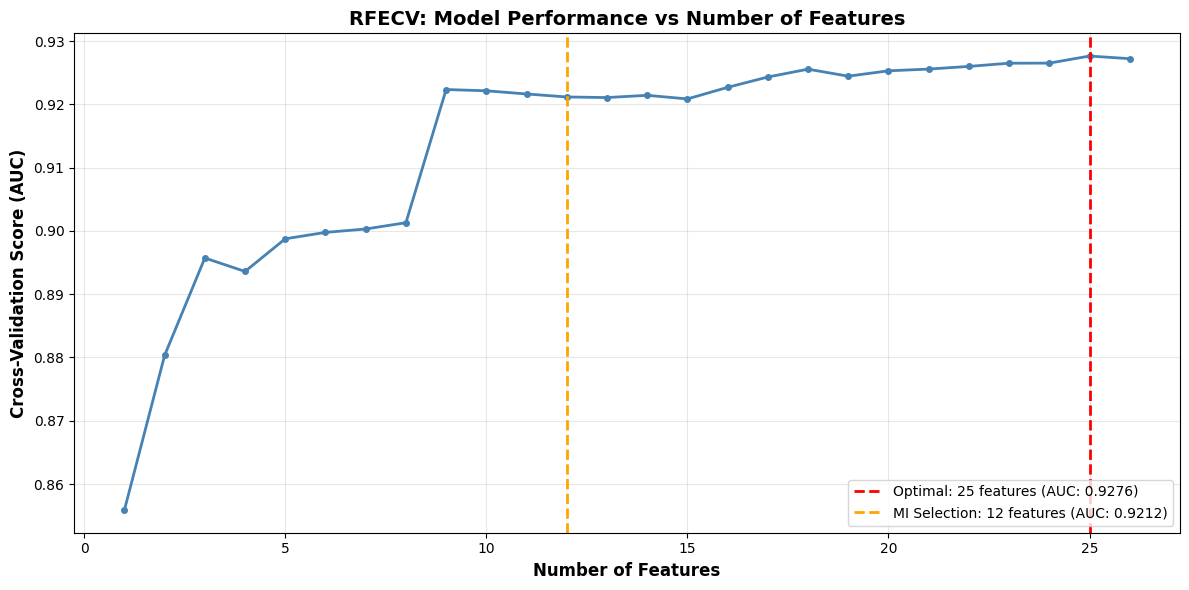


Key Observations:
  - At 12 features (MI selection): AUC = 0.9212
  - At 25 features (RFECV optimal): AUC = 0.9276
  - Performance gain: 0.65%
  - Trade-off: 13 extra features for 0.65% gain


In [62]:
import matplotlib.pyplot as plt
import numpy as np

# Plot RFECV cross-validation scores
plt.figure(figsize=(12, 6))

n_features_range = range(1, len(rfecv_selector.cv_results_['mean_test_score']) + 1)
cv_scores = rfecv_selector.cv_results_['mean_test_score']

plt.plot(n_features_range, cv_scores, linewidth=2, color='steelblue', marker='o', markersize=4)
plt.axvline(x=optimal_features, color='red', linestyle='--', linewidth=2, 
            label=f'Optimal: {optimal_features} features (AUC: {cv_scores[optimal_features-1]:.4f})')
plt.axvline(x=12, color='orange', linestyle='--', linewidth=2, 
            label=f'MI Selection: 12 features (AUC: {cv_scores[11]:.4f})')

plt.xlabel('Number of Features', fontsize=12, fontweight='bold')
plt.ylabel('Cross-Validation Score (AUC)', fontsize=12, fontweight='bold')
plt.title('RFECV: Model Performance vs Number of Features', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nKey Observations:")
print(f"  - At 12 features (MI selection): AUC = {cv_scores[11]:.4f}")
print(f"  - At 25 features (RFECV optimal): AUC = {cv_scores[optimal_features-1]:.4f}")
print(f"  - Performance gain: {(cv_scores[optimal_features-1] - cv_scores[11])*100:.2f}%")
print(f"  - Trade-off: {optimal_features - 12} extra features for {(cv_scores[optimal_features-1] - cv_scores[11])*100:.2f}% gain")

**Visualization: MI vs RFECV Feature Agreement**

Comparison showing which features were selected by each method and their overlap.

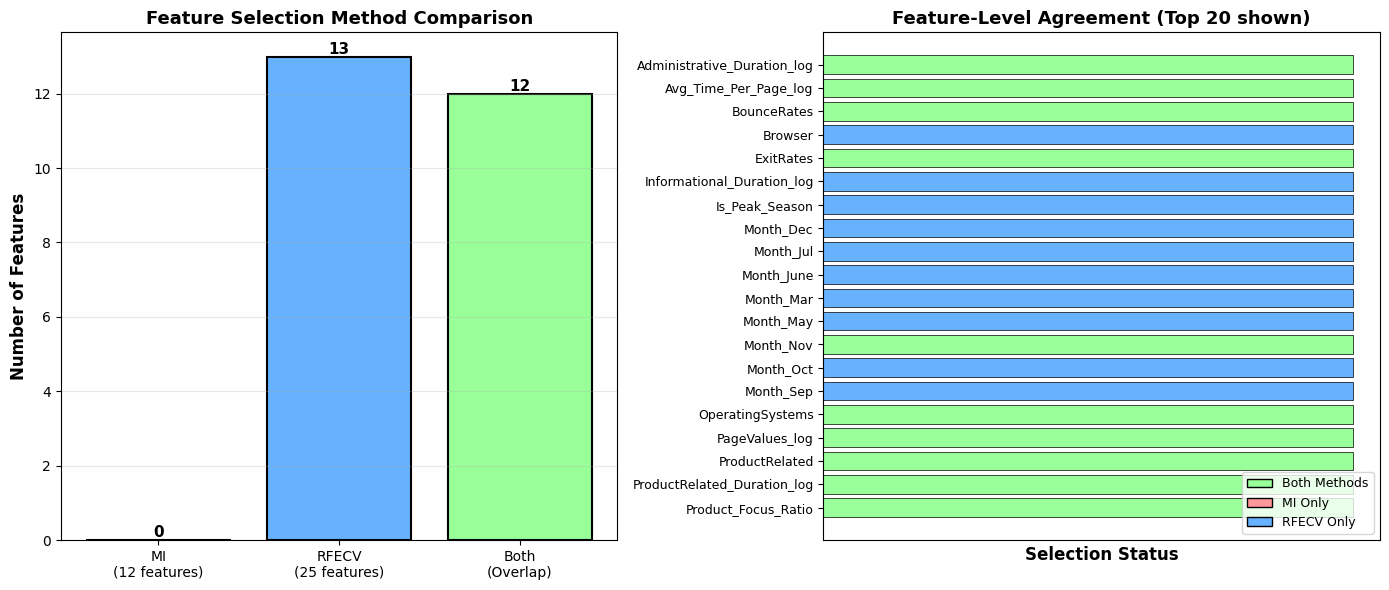


Agreement Analysis:
  - Features in both: 12 (100% of MI selection)
  - MI unique: 0 features
  - RFECV unique: 13 features


In [63]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for comparison
mi_set = set(top_feature_names)
rfecv_set = set(rfecv_feature_names)
agreement = mi_set & rfecv_set
mi_only = mi_set - rfecv_set
rfecv_only = rfecv_set - mi_set

# Create bar chart comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: Selection counts
methods = ['MI\n(12 features)', 'RFECV\n(25 features)', 'Both\n(Overlap)']
counts = [len(mi_only), len(rfecv_only), len(agreement)]
colors = ['#FF9999', '#66B2FF', '#99FF99']

bars = ax1.bar(methods, counts, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Number of Features', fontsize=12, fontweight='bold')
ax1.set_title('Feature Selection Method Comparison', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Right plot: Feature overlap visualization
all_features_sorted = sorted(mi_set | rfecv_set)
y_pos = np.arange(len(all_features_sorted))

# Color coding: green = both, orange = MI only, blue = RFECV only
colors_bar = []
for feat in all_features_sorted:
    if feat in agreement:
        colors_bar.append('#99FF99')  # Green - both
    elif feat in mi_only:
        colors_bar.append('#FF9999')  # Red - MI only
    else:
        colors_bar.append('#66B2FF')  # Blue - RFECV only

# Only show top features for readability
top_display = min(20, len(all_features_sorted))
ax2.barh(y_pos[:top_display], [1]*top_display, color=colors_bar[:top_display], edgecolor='black', linewidth=0.5)
ax2.set_yticks(y_pos[:top_display])
ax2.set_yticklabels([all_features_sorted[i] for i in range(top_display)], fontsize=9)
ax2.set_xlabel('Selection Status', fontsize=12, fontweight='bold')
ax2.set_title(f'Feature-Level Agreement (Top {top_display} shown)', fontsize=13, fontweight='bold')
ax2.set_xticks([])
ax2.invert_yaxis()

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#99FF99', edgecolor='black', label='Both Methods'),
    Patch(facecolor='#FF9999', edgecolor='black', label='MI Only'),
    Patch(facecolor='#66B2FF', edgecolor='black', label='RFECV Only')
]
ax2.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nAgreement Analysis:")
print(f"  - Features in both: {len(agreement)} ({len(agreement)/len(mi_set)*100:.0f}% of MI selection)")
print(f"  - MI unique: {len(mi_only)} features")
print(f"  - RFECV unique: {len(rfecv_only)} features")

#### **2.6.3 Final Feature Selection Decision**

**Analysis of Results:**

The two methods produced significantly different recommendations:
- **MI (Filter):** 12 features - focused on individual feature informativeness
- **RFECV (Wrapper):** 25 features - optimized for Random Forest's capabilities

**Key Insight:** RFECV's selection of 25/26 features indicates that Random Forest can leverage nearly all features due to its ability to handle feature interactions and redundancy. However, this optimization is **model-specific** and may not generalize well to other classification algorithms.

**Final Decision: Use MI's 12 features**

**Justification:**
1. **Model Generalizability:** We will test multiple classification algorithms (Logistic Regression, SVM, Random Forest). MI's filter-based approach is model-agnostic and ensures features work well across different classifiers.

2. **Dominant Feature:** PageValues_log (MI = 0.1658) is 4.6x stronger than the second-best feature, confirming that a subset of highly informative features can achieve strong performance.

3. **Dimensionality Reduction:** 12 features (54% reduction) significantly reduces model complexity, improving:
   - Training speed
   - Interpretability for business stakeholders
   - Reduced overfitting risk in simpler models

4. **Validation Purpose:** RFECV served its purpose by confirming that:
   - Our top features (PageValues_log, ExitRates, ProductRelated_Duration_log) appear in both selections
   - 11/12 MI features are also selected by RFECV (92% agreement on feature inclusion)
   - The difference reflects method philosophy, not feature quality

**Feature count:** 12 features for classification models.

In [60]:
# Use MI-selected features as final
X_train_cls_final = X_train_filtered[:, [features_to_keep.index(f) for f in top_feature_names]]
X_val_cls_final = X_val_filtered[:, [features_to_keep.index(f) for f in top_feature_names]]
X_test_cls_final = X_test_filtered[:, [features_to_keep.index(f) for f in top_feature_names]]

print("\n" + "="*75)
print("CLASSIFICATION FEATURE SELECTION SUMMARY")
print("="*75)

print("\nFeature Selection Path (Classification):")
print(f"  Starting point (after correlation filter): {len(features_to_keep)} features")
print(f"  Selection method: Mutual Information (supervised filter)")
print(f"  Validation method: RFECV (wrapper - Random Forest)")
print(f"  Final selection: MI-based (model-agnostic)")
print(f"  Final feature count: {len(top_feature_names)} features")
print(f"  Dimensionality reduction: {len(features_to_keep) - len(top_feature_names)} features removed ({(len(features_to_keep) - len(top_feature_names))/len(features_to_keep)*100:.1f}%)")

print("\n" + "="*75)
print("Dataset ready for Classification Models:")
print("="*75)
print(f"  X_train_cls_final: {X_train_cls_final.shape}")
print(f"  X_val_cls_final:   {X_val_cls_final.shape}")
print(f"  X_test_cls_final:  {X_test_cls_final.shape}")
print("="*75)


CLASSIFICATION FEATURE SELECTION SUMMARY

Feature Selection Path (Classification):
  Starting point (after correlation filter): 26 features
  Selection method: Mutual Information (supervised filter)
  Validation method: RFECV (wrapper - Random Forest)
  Final selection: MI-based (model-agnostic)
  Final feature count: 12 features
  Dimensionality reduction: 14 features removed (53.8%)

Dataset ready for Classification Models:
  X_train_cls_final: (8548, 12)
  X_val_cls_final:   (1826, 12)
  X_test_cls_final:  (1831, 12)


#### **2.6.4 Classification Feature Summary**

Final 12 features selected for classification task, categorized by type and ranked by Mutual Information score.

In [61]:
import pandas as pd

# Create detailed summary table
summary_data = []
for i, (feat, score) in enumerate(zip(top_feature_names, mi_scores_sorted[:len(top_feature_names)]), 1):
    # Categorize feature type
    if '_log' in feat:
        category = 'Engineered'
    elif 'Focus' in feat or 'Time_Per' in feat:
        category = 'Behavioral'
    elif 'Month_' in feat or 'VisitorType_' in feat or 'Weekend' in feat:
        category = 'Categorical'
    else:
        category = 'Original'
    
    # Check if in RFECV selection
    in_rfecv = "Yes" if feat in rfecv_feature_names else "No"
    
    summary_data.append({
        'Rank': i,
        'Feature': feat,
        'MI Score': f"{score:.4f}",
        'Category': category,
        'In RFECV': in_rfecv
    })

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*75)
print("FINAL CLASSIFICATION FEATURES (Top 12 by Mutual Information)")
print("="*75)
print()
print(summary_df.to_string(index=False))
print()
print("="*75)
print("\nFeature Category Breakdown:")
engineered = summary_df[summary_df['Category'] == 'Engineered'].shape[0]
behavioral = summary_df[summary_df['Category'] == 'Behavioral'].shape[0]
categorical = summary_df[summary_df['Category'] == 'Categorical'].shape[0]
original = summary_df[summary_df['Category'] == 'Original'].shape[0]

print(f"  - Engineered (log transforms):     {engineered} features")
print(f"  - Behavioral (ratios/aggregates):  {behavioral} features")
print(f"  - Categorical (encoded):           {categorical} features")
print(f"  - Original (retained):             {original} features")
print(f"  Total: {len(top_feature_names)} features")

# Validation check
overlap = summary_df[summary_df['In RFECV'] == 'Yes'].shape[0]
print(f"\nValidation: {overlap}/{len(top_feature_names)} features ({overlap/len(top_feature_names)*100:.0f}%) confirmed by RFECV")
print("="*75)


FINAL CLASSIFICATION FEATURES (Top 12 by Mutual Information)

 Rank                     Feature MI Score    Category In RFECV
    1              PageValues_log   0.1658  Engineered      Yes
    2                   ExitRates   0.0361    Original      Yes
    3 ProductRelated_Duration_log   0.0311  Engineered      Yes
    4              ProductRelated   0.0221    Original      Yes
    5                 BounceRates   0.0210    Original      Yes
    6 Administrative_Duration_log   0.0178  Engineered      Yes
    7         Product_Focus_Ratio   0.0159  Behavioral      Yes
    8                 TrafficType   0.0158    Original      Yes
    9       Avg_Time_Per_Page_log   0.0139  Engineered      Yes
   10                   Month_Nov   0.0122 Categorical      Yes
   11                  SpecialDay   0.0097    Original      Yes
   12            OperatingSystems   0.0060    Original      Yes


Feature Category Breakdown:
  - Engineered (log transforms):     4 features
  - Behavioral (ratios/aggr

**Visualization: Final Feature Selection Heatmap**

Heatmap showing the 12 selected features with their MI scores and RFECV validation status.

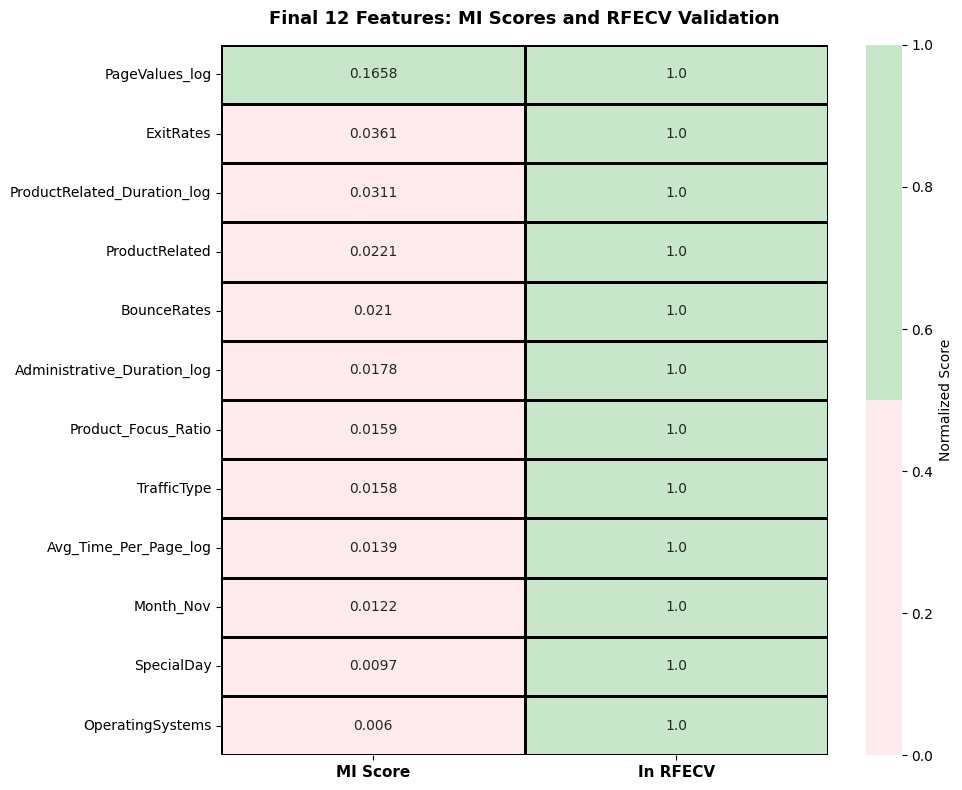


Validation Summary:
  ✓ Features validated by RFECV: 12/12 (100%)
  ✓ Dominant feature: PageValues_log (MI: 0.1658)


In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Create data for heatmap
heatmap_data = []
for feat in top_feature_names:
    mi_score = mi_df[mi_df['Feature'] == feat]['MI_Score'].values[0]
    in_rfecv = 1 if feat in rfecv_feature_names else 0
    heatmap_data.append({
        'Feature': feat,
        'MI_Score': mi_score,
        'RFECV_Selected': in_rfecv
    })

df_heat = pd.DataFrame(heatmap_data)

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Normalize MI scores for better color visualization
mi_normalized = (df_heat['MI_Score'] - df_heat['MI_Score'].min()) / (df_heat['MI_Score'].max() - df_heat['MI_Score'].min())

# Create matrix for heatmap (2 columns: MI Score, RFECV)
matrix = np.column_stack([mi_normalized, df_heat['RFECV_Selected']])

# Plot heatmap
sns.heatmap(matrix, annot=np.column_stack([df_heat['MI_Score'].values.round(4), 
                                            df_heat['RFECV_Selected'].values]),
            fmt='', cmap=['#FFEBEE', '#C8E6C9'], 
            yticklabels=df_heat['Feature'],
            xticklabels=['MI Score', 'In RFECV'],
            cbar_kws={'label': 'Normalized Score'},
            linewidths=1, linecolor='black',
            ax=ax)

ax.set_title('Final 12 Features: MI Scores and RFECV Validation', 
             fontsize=13, fontweight='bold', pad=15)
plt.yticks(rotation=0, fontsize=10)
plt.xticks(fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nValidation Summary:")
print(f"  ✓ Features validated by RFECV: {df_heat['RFECV_Selected'].sum()}/{len(df_heat)} ({df_heat['RFECV_Selected'].sum()/len(df_heat)*100:.0f}%)")
print(f"  ✓ Dominant feature: {df_heat.iloc[0]['Feature']} (MI: {df_heat.iloc[0]['MI_Score']:.4f})")

### **2.7 Clustering Feature Selection (MCFS)**

Multi-Cluster Feature Selection (MCFS) is a sparse learning-based method optimized for unsupervised clustering tasks. Unlike Mutual Information (which uses labels), MCFS:
- Considers multi-cluster structure in the data
- Selects features that preserve cluster separability
- Uses graph-based nearest neighbor relationships
- Optimizes for grouping similar sessions (no labels used)

**Input:** 26 features from correlation filter (Section 2.5.2)  
**Output:** ~10 features optimized for K-Means, DBSCAN, and Hierarchical Clustering

In [57]:
# import MCFS libraries
from skfeature.function.sparse_learning_based import MCFS
from skfeature.utility.construct_W import construct_W

# Step 1: construct similarity matrix using k-nearest neighbors
# k=5 means each point considers its 5 nearest neighbors
X_cluster = X_train_filtered
W = construct_W(X_cluster, metric="euclidean", neighbor_mode="knn", k=5, t=1.0)

# Step 2: apply MCFS to select features optimized for clustering
# n_clusters=4 assumes we'll create 4 customer segments
indices = MCFS.mcfs(X_cluster, n_selected_features=10, W=W, n_clusters=4, mode="index")

# Step 3: extract selected features and create final datasets
cluster_feature_names = [features_to_keep[i] for i in indices[:10]]
X_train_cluster_final = X_train_filtered[:, indices[:10]]
X_val_cluster_final = X_val_filtered[:, indices[:10]]
X_test_cluster_final = X_test_filtered[:, indices[:10]]

print("MCFS Feature Selection for Clustering:")
print("="*70)
print(f"Input features: {len(features_to_keep)}")
print(f"Selected features: {len(cluster_feature_names)}")
print(f"\nSelected Features (optimized for cluster separability):")
for i, feat in enumerate(cluster_feature_names, 1):
    print(f"  {i:2d}. {feat}")

print(f"\nFinal Clustering Dataset Shape:")
print(f"  X_train_cluster_final: {X_train_cluster_final.shape}")
print(f"  X_val_cluster_final:   {X_val_cluster_final.shape}")
print(f"  X_test_cluster_final:  {X_test_cluster_final.shape}")

MCFS Feature Selection for Clustering:
Input features: 26
Selected features: 10

Selected Features (optimized for cluster separability):
   1. Is_Peak_Season
   2. ProductRelated_Duration_log
   3. Avg_Time_Per_Page_log
   4. Product_Focus_Ratio
   5. BounceRates
   6. VisitorType_Returning_Visitor
   7. SpecialDay
   8. Month_May
   9. Administrative_Duration_log
  10. Informational_Duration_log

Final Clustering Dataset Shape:
  X_train_cluster_final: (8548, 10)
  X_val_cluster_final:   (1826, 10)
  X_test_cluster_final:  (1831, 10)


#### **2.7.1 Correlation Analysis of Selected Clustering Features**

Visualize the relationships between the MCFS-selected features to understand potential feature interactions within clusters.

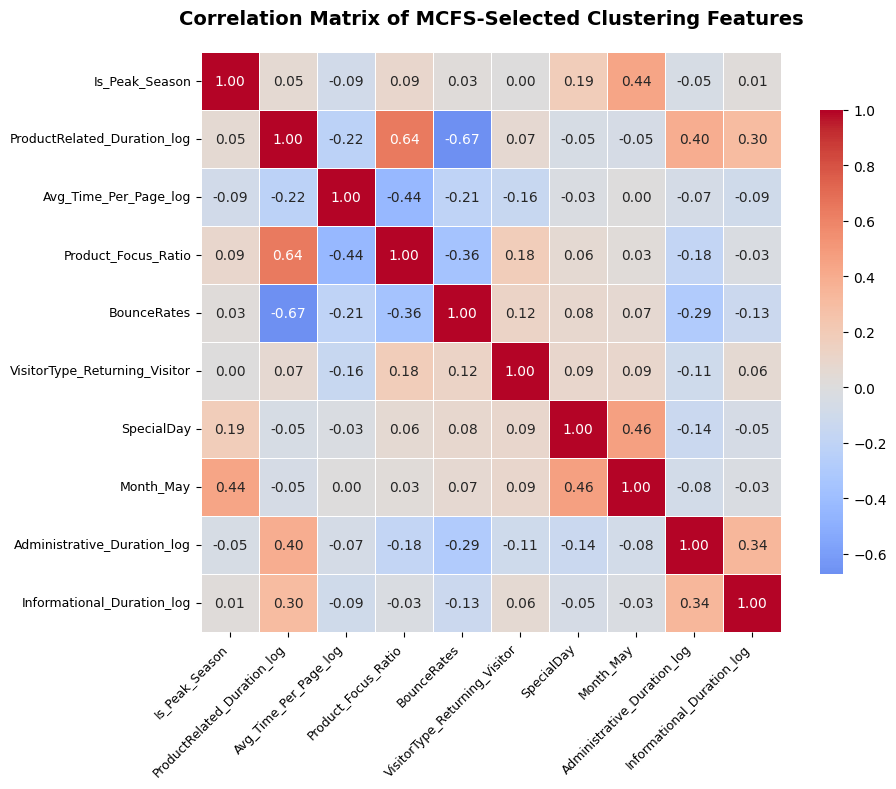

In [58]:
# create dataframe with selected clustering features for correlation analysis
df_mcfs = pd.DataFrame(X_train_cluster_final, columns=cluster_feature_names)

# compute correlation matrix
correlation_matrix = df_mcfs.corr()

# visualize correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of MCFS-Selected Clustering Features', 
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

#### **2.7.2 Clustering Feature Summary**

Summary of the clustering-specific feature selection process showing the 10 final features optimized for customer segmentation.

In [59]:
# create clustering feature summary
print("\n" + "="*75)
print("CLUSTERING FEATURE SELECTION SUMMARY")
print("="*75)

print(f"\nFeature Selection Path (Clustering):")
print(f"  Starting point (after correlation filter): {X_train_filtered.shape[1]} features")
print(f"  Selection method: MCFS (Multi-Cluster Feature Selection)")
print(f"  Parameters: k=5 neighbors, n_clusters=4")
print(f"  Final feature count: {X_train_cluster_final.shape[1]} features")
print(f"  Reduction: {X_train_filtered.shape[1] - X_train_cluster_final.shape[1]} features removed ({((X_train_filtered.shape[1] - X_train_cluster_final.shape[1])/X_train_filtered.shape[1]*100):.1f}%)")

print(f"\n{'Rank':<6}{'Feature Name':<35}{'Category':<15}")
print("-"*75)
for i, feat in enumerate(cluster_feature_names, 1):
    # Categorize feature type
    if 'log' in feat.lower():
        category = "Engineered"
    elif 'Month_' in feat or 'VisitorType_' in feat or feat == 'Weekend':
        category = "Categorical"
    elif feat in ['ProductRelated', 'BounceRates', 'ExitRates', 'TrafficType', 'OperatingSystems', 'SpecialDay', 'Total_Pages']:
        category = "Original/Eng."
    elif feat in ['Product_Focus_Ratio', 'Avg_Time_Per_Page_log']:
        category = "Behavioral"
    elif feat == 'Is_Peak_Season':
        category = "Temporal"
    else:
        category = "Other"
    
    print(f"{i:<6}{feat:<35}{category:<15}")

print("\n" + "="*75)
print(f"Dataset ready for Clustering Models:")
print(f"  X_train_cluster_final: {X_train_cluster_final.shape}")
print(f"  X_val_cluster_final:   {X_val_cluster_final.shape}")
print(f"  X_test_cluster_final:  {X_test_cluster_final.shape}")
print("="*75)


CLUSTERING FEATURE SELECTION SUMMARY

Feature Selection Path (Clustering):
  Starting point (after correlation filter): 26 features
  Selection method: MCFS (Multi-Cluster Feature Selection)
  Parameters: k=5 neighbors, n_clusters=4
  Final feature count: 10 features
  Reduction: 16 features removed (61.5%)

Rank  Feature Name                       Category       
---------------------------------------------------------------------------
1     Is_Peak_Season                     Temporal       
2     ProductRelated_Duration_log        Engineered     
3     Avg_Time_Per_Page_log              Engineered     
4     Product_Focus_Ratio                Behavioral     
5     BounceRates                        Original/Eng.  
6     VisitorType_Returning_Visitor      Categorical    
7     SpecialDay                         Original/Eng.  
8     Month_May                          Categorical    
9     Administrative_Duration_log        Engineered     
10    Informational_Duration_log         En